# 📊 Project FORESIGHT
## AI-Powered Demand & Inventory Intelligence Platform
### Notebook 04: Baseline Forecasting

---

## 📌 Project Information

| Item | Details |
|---|---|
| **Author** | Mohit Kumar |
| **Internship** | Zidio Development |
| **Project Type** | End-to-End Data Analytics & Machine Learning Project |
| **Notebook Version** | 1.0 |
| **Status** | Completed |
| **Last Updated** | August 2026 |

---------

## 🎯 1. Business Context and Notebook Objective

A forecasting system needs a transparent and honestly evaluated benchmark before more complex models can be trusted. Machine-learning models developed later in Project FORESIGHT must demonstrate a reliable improvement over this benchmark rather than being selected only because they are more advanced.

Notebook 04 uses the validated weekly modelling dataset created in Notebook 03 to develop and compare statistical baseline forecasts for the approved 300 SKU-store series.

This notebook will:

- establish a leakage-safe chronological evaluation design;
- implement naive, seasonal-naive, moving-average and exponential-smoothing baselines;
- compare all candidates using identical validation periods and series coverage;
- select the champion baseline using validation evidence only;
- evaluate the champion once on the untouched final-test period;
- export the benchmark forecasts, metrics and configuration required by Notebook 05.

> **Scope boundary:** This notebook covers baseline forecasting only. Machine-learning modelling belongs to Notebook 05, final baseline-versus-ML selection belongs to Notebook 06, and inventory decisioning belongs to Notebook 07.

-------

## ⚙️ 2. Setup and Notebook 03 Handoff

This section prepares the forecasting environment and loads the approved Notebook 03 output. Only the minimum checks required for reliable baseline forecasting will be performed.

### 2.1 Environment, Paths and Input Loading

The required forecasting, data-handling and visualisation libraries will be imported, reproducibility settings will be established, and project paths will be defined.

The final weekly modelling dataset, `weekly_features_final.csv`, and only the supporting metadata required by this notebook will then be loaded. No data cleaning, EDA or feature reconstruction will be repeated.

In [1]:
# Core data and utility libraries
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display and forecasting libraries
from IPython.display import display
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    ExponentialSmoothing
)

# Reproducibility and warning controls
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Display and visualisation settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Environment setup completed successfully.")
print(f"Random seed: {RANDOM_SEED}")

Environment setup completed successfully.
Random seed: 42


### 📝 Library Summary

The required Python libraries were successfully imported and configured for Notebook 04. Each library supports a specific part of the baseline forecasting workflow.

| Library | Purpose |
|---|---|
| **pandas** | Loading, structuring, aggregating and validating forecasting data |
| **NumPy** | Numerical calculations, array operations and reproducibility controls |
| **Matplotlib** | Creation of forecasting diagnostics and performance charts |
| **Seaborn** | Statistical visualisation and consistent chart styling |
| **Pathlib** | Reproducible project-directory and file-path management |
| **JSON** | Reading and exporting champion-model configuration metadata |
| **IPython.display** | Enhanced display of tables and notebook outputs |
| **statsmodels** | Simple and damped-trend exponential-smoothing baselines |

The random seed, display settings, warning controls and visualisation theme have also been configured consistently.

The notebook environment is now prepared for modelling-data loading and baseline forecasting.

In [2]:
# Resolve the Project FORESIGHT directory
NOTEBOOK_DIR = Path.cwd().resolve()

if NOTEBOOK_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Define the approved Notebook 03 handoff path
DATA_DIR = PROJECT_ROOT / "data"
MODELING_DATA_DIR = DATA_DIR / "modeling"
INPUT_DATA_PATH = MODELING_DATA_DIR / "weekly_features_final.csv"

# Confirm that the required forecasting input exists
if not INPUT_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Required Notebook 03 output was not found: {INPUT_DATA_PATH}"
    )

# Prepare portable project-relative paths for display
MODELING_DATA_DISPLAY = (
    MODELING_DATA_DIR
    .relative_to(PROJECT_ROOT)
    .as_posix()
)

INPUT_DATA_DISPLAY = (
    INPUT_DATA_PATH
    .relative_to(PROJECT_ROOT)
    .as_posix()
)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Modelling data directory: {MODELING_DATA_DISPLAY}")
print(f"Forecasting input: {INPUT_DATA_DISPLAY}")
print(f"Input file available: {INPUT_DATA_PATH.is_file()}")

Project root: Project FORESIGHT
Modelling data directory: data/modeling
Forecasting input: data/modeling/weekly_features_final.csv
Input file available: True


In [3]:
# Define the exact Notebook 03 handoff contract
MODEL_IDENTIFIER_COLUMNS = [
    "sku_id",
    "wm_yr_wk",
    "week_start_date",
    "week_end_date",
]

MODEL_KEY_COLUMNS = [
    "sku_id",
    "wm_yr_wk",
]

DATE_COLUMNS = [
    "week_start_date",
    "week_end_date",
]

TARGET_COLUMN = "weekly_units_sold"
EXPECTED_DATASET_SHAPE = (66_300, 44)

# Verify the persisted CSV header before loading the complete dataset
persisted_columns = pd.read_csv(
    INPUT_DATA_PATH,
    nrows=0
).columns.tolist()

required_columns = [
    *MODEL_IDENTIFIER_COLUMNS,
    TARGET_COLUMN,
]

missing_required_columns = [
    column
    for column in required_columns
    if column not in persisted_columns
]

if missing_required_columns:
    raise KeyError(
        "Notebook 03 handoff columns are missing: "
        f"{missing_required_columns}"
    )

# Load the approved Notebook 03 modelling dataset
weekly_features = pd.read_csv(
    INPUT_DATA_PATH,
    parse_dates=DATE_COLUMNS,
    low_memory=False
)

# Confirm the approved export dimensions
if weekly_features.shape != EXPECTED_DATASET_SHAPE:
    raise ValueError(
        "Unexpected Notebook 03 handoff dimensions. "
        f"Expected {EXPECTED_DATASET_SHAPE}, "
        f"but found {weekly_features.shape}."
    )

print("Forecasting dataset loaded successfully.")
print(
    f"Dataset shape: "
    f"{weekly_features.shape[0]:,} rows × "
    f"{weekly_features.shape[1]:,} columns"
)
print(f"Series column: {MODEL_IDENTIFIER_COLUMNS[0]}")
print(f"Weekly time column: {DATE_COLUMNS[0]}")
print(f"Forecasting target: {TARGET_COLUMN}")
print(
    "Date columns parsed: "
    f"{weekly_features[DATE_COLUMNS].dtypes.apply(str).to_dict()}"
)

display(
    weekly_features[
        MODEL_IDENTIFIER_COLUMNS + [TARGET_COLUMN]
    ].head(3)
)

Forecasting dataset loaded successfully.
Dataset shape: 66,300 rows × 44 columns
Series column: sku_id
Weekly time column: week_start_date
Forecasting target: weekly_units_sold
Date columns parsed: {'week_start_date': 'datetime64[us]', 'week_end_date': 'datetime64[us]'}


,sku_id,wm_yr_wk,week_start_date,week_end_date,weekly_units_sold
0,FOODS_1_001_CA_1,11201,2012-01-28,2012-02-03,7
1,FOODS_1_001_CA_1,11202,2012-02-04,2012-02-10,5
2,FOODS_1_001_CA_1,11203,2012-02-11,2012-02-17,6


### 📝 Setup and Input Summary

The notebook environment, reusable project paths and approved Notebook 03 modelling handoff were initialized successfully. The weekly dataset loaded under its verified schema and is ready for time-based validation.

> This step confirms input accessibility and schema compatibility; complete forecasting readiness is evaluated separately in Section 2.2.

### 2.2 Minimal Input Readiness Check

A compact downstream-readiness check will confirm that the forecasting target, series identifiers and weekly time field are available and valid.

The check will also confirm 300 SKU-store series, unique SKU-store-week records, chronological ordering, usable target values and the weekly continuity required by the baseline methods.

> This is a forecasting safety gate, not a repeat of the comprehensive validation and leakage controls completed in Notebooks 01 and 03.

In [4]:
# Reuse the verified Notebook 03 handoff contract
SERIES_COLUMN = MODEL_IDENTIFIER_COLUMNS[0]

EXPECTED_SERIES_COUNT = 300

# Calculate observed readiness results
observed_series_count = weekly_features[SERIES_COLUMN].nunique(
    dropna=True
)

missing_key_value_count = int(
    weekly_features[MODEL_KEY_COLUMNS]
    .isna()
    .sum()
    .sum()
)

duplicate_key_count = int(
    weekly_features.duplicated(
        subset=MODEL_KEY_COLUMNS
    ).sum()
)

target_is_numeric = pd.api.types.is_numeric_dtype(
    weekly_features[TARGET_COLUMN]
)

target_numeric = pd.to_numeric(
    weekly_features[TARGET_COLUMN],
    errors="coerce"
)

invalid_target_count = int(
    (~np.isfinite(target_numeric.to_numpy(dtype=float))).sum()
)

negative_target_count = int(
    (target_numeric < 0).sum()
)

# Build a transparent readiness-check table
core_readiness_results = pd.DataFrame({
    "Check": [
        "Approved SKU-store series coverage",
        "Missing values in model key",
        "Duplicate SKU-store-week keys",
        "Numeric forecasting target",
        "Missing or non-finite target values",
        "Negative target values",
    ],
    "Observed Result": [
        f"{observed_series_count:,} series",
        f"{missing_key_value_count:,} values",
        f"{duplicate_key_count:,} rows",
        str(target_is_numeric),
        f"{invalid_target_count:,} values",
        f"{negative_target_count:,} values",
    ],
    "Required Result": [
        f"{EXPECTED_SERIES_COUNT:,} series",
        "0 values",
        "0 rows",
        "True",
        "0 values",
        "0 values",
    ],
    "Status": [
        "PASS" if observed_series_count == EXPECTED_SERIES_COUNT else "FAIL",
        "PASS" if missing_key_value_count == 0 else "FAIL",
        "PASS" if duplicate_key_count == 0 else "FAIL",
        "PASS" if target_is_numeric else "FAIL",
        "PASS" if invalid_target_count == 0 else "FAIL",
        "PASS" if negative_target_count == 0 else "FAIL",
    ],
})

display(core_readiness_results)

failed_core_checks = core_readiness_results.loc[
    core_readiness_results["Status"] == "FAIL",
    "Check"
].tolist()

if failed_core_checks:
    raise ValueError(
        "Core input-readiness checks failed: "
        f"{failed_core_checks}"
    )

print("Core input-readiness checks passed successfully.")

,Check,Observed Result,Required Result,Status
0,Approved SKU-store series coverage,300 series,300 series,PASS
1,Missing values in model key,0 values,0 values,PASS
2,Duplicate SKU-store-week keys,0 rows,0 rows,PASS
3,Numeric forecasting target,True,True,PASS
4,Missing or non-finite target values,0 values,0 values,PASS
5,Negative target values,0 values,0 values,PASS


Core input-readiness checks passed successfully.


In [5]:
# Reuse the verified weekly-date contract
START_DATE_COLUMN = DATE_COLUMNS[0]
END_DATE_COLUMN = DATE_COLUMNS[1]

EXPECTED_WEEK_STEP = pd.Timedelta(days=7)
EXPECTED_WEEK_SPAN = pd.Timedelta(days=6)

# Check weekly-date completeness
missing_weekly_date_count = int(
    weekly_features[DATE_COLUMNS]
    .isna()
    .sum()
    .sum()
)

# Check whether records are already chronological within each series
original_order_steps = (
    weekly_features
    .groupby(SERIES_COLUMN, sort=False)[START_DATE_COLUMN]
    .diff()
)

chronological_order_violation_count = int(
    (original_order_steps <= pd.Timedelta(0)).sum()
)

# Check uniqueness of the series-date combination
duplicate_series_date_count = int(
    weekly_features.duplicated(
        subset=[SERIES_COLUMN, START_DATE_COLUMN]
    ).sum()
)

# Sort a temporary validation frame without modifying the source dataset
continuity_frame = (
    weekly_features[
        [SERIES_COLUMN, START_DATE_COLUMN, END_DATE_COLUMN]
    ]
    .sort_values(
        [SERIES_COLUMN, START_DATE_COLUMN],
        kind="mergesort"
    )
    .reset_index(drop=True)
)

# Check for non-weekly intervals within each series
observed_week_steps = (
    continuity_frame
    .groupby(SERIES_COLUMN, sort=False)[START_DATE_COLUMN]
    .diff()
)

non_weekly_interval_count = int(
    observed_week_steps
    .dropna()
    .ne(EXPECTED_WEEK_STEP)
    .sum()
)

# Confirm that every weekly record spans seven consecutive calendar days
observed_week_spans = (
    continuity_frame[END_DATE_COLUMN]
    - continuity_frame[START_DATE_COLUMN]
)

invalid_week_span_count = int(
    observed_week_spans
    .dropna()
    .ne(EXPECTED_WEEK_SPAN)
    .sum()
)

# Calculate series-level coverage dynamically
series_time_coverage = (
    continuity_frame
    .groupby(SERIES_COLUMN)
    .agg(
        observed_weeks=(START_DATE_COLUMN, "nunique"),
        first_week=(START_DATE_COLUMN, "min"),
        last_week=(START_DATE_COLUMN, "max"),
    )
)

minimum_weeks = int(
    series_time_coverage["observed_weeks"].min()
)

maximum_weeks = int(
    series_time_coverage["observed_weeks"].max()
)

unique_start_date_count = int(
    series_time_coverage["first_week"].nunique()
)

unique_end_date_count = int(
    series_time_coverage["last_week"].nunique()
)

equal_series_coverage = minimum_weeks == maximum_weeks

aligned_date_window = (
    unique_start_date_count == 1
    and unique_end_date_count == 1
)

# Build the validation table
time_readiness_results = pd.DataFrame({
    "Check": [
        "Missing weekly-date values",
        "Non-chronological records within series",
        "Duplicate SKU-store-date records",
        "Non-seven-day intervals",
        "Invalid weekly date spans",
        "Equal observations across series",
        "Aligned date window across series",
    ],
    "Observed Result": [
        f"{missing_weekly_date_count:,} values",
        f"{chronological_order_violation_count:,} rows",
        f"{duplicate_series_date_count:,} rows",
        f"{non_weekly_interval_count:,} intervals",
        f"{invalid_week_span_count:,} rows",
        (
            f"{minimum_weeks:,} weeks per series"
            if equal_series_coverage
            else f"{minimum_weeks:,}–{maximum_weeks:,} weeks"
        ),
        (
            f"{unique_start_date_count} start date; "
            f"{unique_end_date_count} end date"
        ),
    ],
    "Required Result": [
        "0 values",
        "0 rows",
        "0 rows",
        "0 intervals",
        "0 rows",
        "Same count for every series",
        "1 common start and end date",
    ],
    "Status": [
        "PASS" if missing_weekly_date_count == 0 else "FAIL",
        (
            "PASS"
            if chronological_order_violation_count == 0
            else "FAIL"
        ),
        "PASS" if duplicate_series_date_count == 0 else "FAIL",
        "PASS" if non_weekly_interval_count == 0 else "FAIL",
        "PASS" if invalid_week_span_count == 0 else "FAIL",
        "PASS" if equal_series_coverage else "FAIL",
        "PASS" if aligned_date_window else "FAIL",
    ],
})

display(time_readiness_results)

failed_time_checks = time_readiness_results.loc[
    time_readiness_results["Status"] == "FAIL",
    "Check"
].tolist()

if failed_time_checks:
    raise ValueError(
        "Chronology or weekly-continuity checks failed: "
        f"{failed_time_checks}"
    )

print("Chronology and weekly-continuity checks passed successfully.")

,Check,Observed Result,Required Result,Status
0,Missing weekly-date values,0 values,0 values,PASS
1,Non-chronological records within series,0 rows,0 rows,PASS
2,Duplicate SKU-store-date records,0 rows,0 rows,PASS
3,Non-seven-day intervals,0 intervals,0 intervals,PASS
4,Invalid weekly date spans,0 rows,0 rows,PASS
5,Equal observations across series,221 weeks per series,Same count for every series,PASS
6,Aligned date window across series,1 start date; 1 end date,1 common start and end date,PASS


Chronology and weekly-continuity checks passed successfully.


### 📝 Input Readiness Summary

Together, the core and time-based validations confirm that every modelling record belongs to a reliable, chronologically ordered weekly series. The handoff can therefore support leakage-safe forecasting and evaluation without additional structural correction.

### ✅ Section 2 Final Summary

The verified modelling handoff is ready for forecasting. Section 3 now defines the leakage-safe validation and final-test design.

---

## 🗓️ 3. Forecasting and Evaluation Design

This section establishes a consistent, leakage-safe framework for comparing all forecasting candidates before model performance is assessed.

### 3.1 Forecast Horizon and Chronological Splits

The task is to forecast weekly units sold for every SKU-store series across an eight-week horizon.

Model comparison will use three rolling-origin validation folds with expanding training windows. The latest eight weeks will remain an untouched final test and will not influence model comparison or champion selection.

At each origin, the model will be trained only on the history available at that time and will forecast the next eight weeks, reproducing the sequence required in real-world use.


In [6]:
# Define the forecasting configuration
FORECAST_HORIZON = 8
N_VALIDATION_FOLDS = 3
FINAL_TEST_WEEKS = 8
SEASONAL_PERIOD = 52

# Recover the verified weekly calendar
ALL_WEEKS = pd.DatetimeIndex(
    weekly_features[START_DATE_COLUMN]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

TOTAL_WEEKS = len(ALL_WEEKS)

RESERVED_EVALUATION_WEEKS = (
    N_VALIDATION_FOLDS * FORECAST_HORIZON
    + FINAL_TEST_WEEKS
)

FIRST_VALIDATION_TRAINING_WEEKS = (
    TOTAL_WEEKS - RESERVED_EVALUATION_WEEKS
)

MINIMUM_REQUIRED_WEEKS = (
    SEASONAL_PERIOD + RESERVED_EVALUATION_WEEKS
)

if TOTAL_WEEKS < MINIMUM_REQUIRED_WEEKS:
    raise ValueError(
        f"The design requires at least {MINIMUM_REQUIRED_WEEKS} weeks, "
        f"but only {TOTAL_WEEKS} were found."
    )

# Display the configured design
forecast_design_config = pd.DataFrame({
    "Design Component": [
        "Available panel history",
        "Forecast horizon",
        "Validation folds",
        "Final-test horizon",
        "Reserved evaluation window",
        "First validation training window",
        "Seasonal reference period",
    ],
    "Configured Value": [
        f"{TOTAL_WEEKS:,} weeks",
        f"{FORECAST_HORIZON} weeks",
        f"{N_VALIDATION_FOLDS} folds",
        f"{FINAL_TEST_WEEKS} weeks",
        f"{RESERVED_EVALUATION_WEEKS} weeks",
        f"{FIRST_VALIDATION_TRAINING_WEEKS:,} weeks",
        f"{SEASONAL_PERIOD} weeks",
    ],
})

display(forecast_design_config)

,Design Component,Configured Value
0,Available panel history,221 weeks
1,Forecast horizon,8 weeks
2,Validation folds,3 folds
3,Final-test horizon,8 weeks
4,Reserved evaluation window,32 weeks
5,First validation training window,189 weeks
6,Seasonal reference period,52 weeks


In [7]:
# Determine the start of each validation window
validation_start_indices = [
    TOTAL_WEEKS
    - FINAL_TEST_WEEKS
    - (
        N_VALIDATION_FOLDS - fold_number + 1
    ) * FORECAST_HORIZON
    for fold_number in range(
        1,
        N_VALIDATION_FOLDS + 1
    )
]

# Define validation and final-test windows
split_specs = [
    (
        f"validation_fold_{fold_number}",
        "validation",
        start_index,
        FORECAST_HORIZON,
    )
    for fold_number, start_index in enumerate(
        validation_start_indices,
        start=1,
    )
]

split_specs.append((
    "final_test",
    "final_test",
    TOTAL_WEEKS - FINAL_TEST_WEEKS,
    FINAL_TEST_WEEKS,
))

# Construct the chronological split records
split_records = []

for (
    split_id,
    split_type,
    evaluation_start_index,
    forecast_weeks,
) in split_specs:

    training_end_index = evaluation_start_index - 1
    evaluation_end_index = (
        evaluation_start_index + forecast_weeks - 1
    )

    split_records.append({
        "split_id": split_id,
        "split_type": split_type,
        "training_weeks": evaluation_start_index,
        "train_start": ALL_WEEKS[0],
        "train_end": ALL_WEEKS[training_end_index],
        "forecast_origin": ALL_WEEKS[training_end_index],
        "evaluation_start": ALL_WEEKS[
            evaluation_start_index
        ],
        "evaluation_end": ALL_WEEKS[
            evaluation_end_index
        ],
        "forecast_weeks": forecast_weeks,
    })

forecast_split_definitions = pd.DataFrame(
    split_records
)

# Preserve the complete split schedule
split_schedule = forecast_split_definitions[
    [
        "split_id",
        "split_type",
        "training_weeks",
        "train_start",
        "train_end",
        "evaluation_start",
        "evaluation_end",
        "forecast_weeks",
    ]
].copy()

split_schedule.columns = [
    "Split",
    "Purpose",
    "Training Weeks",
    "Training Start",
    "Training End",
    "Evaluation Start",
    "Evaluation End",
    "Forecast Weeks",
]

split_schedule["Purpose"] = (
    split_schedule["Purpose"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

date_columns = [
    "Training Start",
    "Training End",
    "Evaluation Start",
    "Evaluation End",
]

for column in date_columns:
    split_schedule[column] = (
        pd.to_datetime(split_schedule[column])
        .dt.strftime("%Y-%m-%d")
    )

# Prepare a compact PDF-safe display
split_schedule_display = split_schedule[
    [
        "Split",
        "Purpose",
        "Training Weeks",
        "Training End",
        "Evaluation Start",
        "Evaluation End",
        "Forecast Weeks",
    ]
].copy()

split_schedule_display["Evaluation Window"] = (
    split_schedule_display["Evaluation Start"]
    + " to "
    + split_schedule_display["Evaluation End"]
)

split_schedule_display = (
    split_schedule_display.drop(
        columns=[
            "Evaluation Start",
            "Evaluation End",
        ]
    )
    .rename(
        columns={
            "Training End": "Train Through",
            "Forecast Weeks": "Horizon",
        }
    )
)

split_schedule_display["Split"] = (
    split_schedule_display["Split"]
    .str.replace("validation_fold_", "Fold ", regex=False)
    .str.replace("final_test", "Final Test", regex=False)
)

display(split_schedule_display)

,Split,Purpose,Training Weeks,Train Through,Horizon,Evaluation Window
0,Fold 1,Validation,189,2015-09-05,8,2015-09-12 to 2015-10-31
1,Fold 2,Validation,197,2015-10-31,8,2015-11-07 to 2015-12-26
2,Fold 3,Validation,205,2015-12-26,8,2016-01-02 to 2016-02-20
3,Final Test,Final Test,213,2016-02-20,8,2016-02-27 to 2016-04-16


In [8]:
# Recover all reserved evaluation dates
evaluation_windows = [
    ALL_WEEKS[
        start_index:start_index + forecast_weeks
    ].tolist()
    for _, _, start_index, forecast_weeks in split_specs
]

reserved_evaluation_dates = [
    date
    for window in evaluation_windows
    for date in window
]

expected_reserved_dates = ALL_WEEKS[
    -RESERVED_EVALUATION_WEEKS:
].tolist()

# Calculate validation evidence
validation_split_count = int(
    forecast_split_definitions["split_type"]
    .eq("validation")
    .sum()
)

final_test_count = int(
    forecast_split_definitions["split_type"]
    .eq("final_test")
    .sum()
)

invalid_horizon_count = int(
    forecast_split_definitions["forecast_weeks"]
    .ne(FORECAST_HORIZON)
    .sum()
)

invalid_boundary_count = int(
    (
        forecast_split_definitions["evaluation_start"]
        - forecast_split_definitions["train_end"]
    )
    .ne(pd.Timedelta(weeks=1))
    .sum()
)

invalid_expansion_count = int(
    forecast_split_definitions["training_weeks"]
    .diff()
    .dropna()
    .ne(FORECAST_HORIZON)
    .sum()
)

overlapping_week_count = (
    len(reserved_evaluation_dates)
    - len(set(reserved_evaluation_dates))
)

latest_window_reserved = (
    reserved_evaluation_dates
    == expected_reserved_dates
)

# Confirm complete SKU-store coverage
expected_series_count = int(
    weekly_features[SERIES_COLUMN].nunique()
)

evaluation_coverage = (
    weekly_features.loc[
        weekly_features[START_DATE_COLUMN].isin(
            reserved_evaluation_dates
        )
    ]
    .groupby(START_DATE_COLUMN)[SERIES_COLUMN]
    .nunique()
)

complete_evaluation_coverage = (
    len(evaluation_coverage)
    == RESERVED_EVALUATION_WEEKS
    and evaluation_coverage.eq(
        expected_series_count
    ).all()
)

# Build the validation register
split_validation_results = pd.DataFrame({
    "Check": [
        "Required split composition",
        "Uniform forecast horizons",
        "Consecutive train-evaluation boundaries",
        "Eight-week training expansion",
        "Non-overlapping evaluation windows",
        "Latest continuous period reserved",
        "Complete SKU-store coverage",
    ],
    "Observed Result": [
        (
            f"{validation_split_count} validation; "
            f"{final_test_count} final test"
        ),
        f"{invalid_horizon_count} invalid splits",
        f"{invalid_boundary_count} invalid boundaries",
        f"{invalid_expansion_count} invalid expansions",
        f"{overlapping_week_count} overlapping weeks",
        (
            f"Latest {RESERVED_EVALUATION_WEEKS} weeks"
            if latest_window_reserved
            else "Incorrect reserved period"
        ),
        (
            f"{expected_series_count} series in every week"
            if complete_evaluation_coverage
            else "Incomplete weekly coverage"
        ),
    ],
    "Required Result": [
        "3 validation; 1 final test",
        "0 invalid splits",
        "0 invalid boundaries",
        "0 invalid expansions",
        "0 overlapping weeks",
        "Latest 32 weeks",
        "300 series in every week",
    ],
    "Status": [
        (
            "PASS"
            if (
                validation_split_count
                == N_VALIDATION_FOLDS
                and final_test_count == 1
            )
            else "FAIL"
        ),
        "PASS" if invalid_horizon_count == 0 else "FAIL",
        "PASS" if invalid_boundary_count == 0 else "FAIL",
        "PASS" if invalid_expansion_count == 0 else "FAIL",
        "PASS" if overlapping_week_count == 0 else "FAIL",
        "PASS" if latest_window_reserved else "FAIL",
        (
            "PASS"
            if complete_evaluation_coverage
            else "FAIL"
        ),
    ],
})

display(split_validation_results)

failed_split_checks = split_validation_results.loc[
    split_validation_results["Status"] == "FAIL",
    "Check"
].tolist()

if failed_split_checks:
    raise ValueError(
        f"Chronological split checks failed: "
        f"{failed_split_checks}"
    )


,Check,Observed Result,Required Result,Status
0,Required split composition,3 validation; 1 final test,3 validation; 1 final test,PASS
1,Uniform forecast horizons,0 invalid splits,0 invalid splits,PASS
2,Consecutive train-evaluation boundaries,0 invalid boundaries,0 invalid boundaries,PASS
3,Eight-week training expansion,0 invalid expansions,0 invalid expansions,PASS
4,Non-overlapping evaluation windows,0 overlapping weeks,0 overlapping weeks,PASS
5,Latest continuous period reserved,Latest 32 weeks,Latest 32 weeks,PASS
6,Complete SKU-store coverage,300 series in every week,300 series in every week,PASS


### 📝 Chronological Split Summary

The validated schedule preserves temporal order, consistent evaluation coverage and complete separation between training and forecast periods. All candidates can therefore be compared fairly, while the latest period remains protected for unbiased final testing.

### 3.2 Metrics and Forecasting Rules

Validation WAPE will serve as the primary model-selection metric. Forecast Bias, MAE and RMSE will provide supporting evidence on directional error, overall error magnitude and sensitivity to larger misses.

All candidates must use identical forecast origins, horizon lengths and SKU-store coverage. Predictions must remain non-negative, and every feature must be available at the corresponding forecast origin.

When future lag-based inputs depend on unknown demand, preceding predictions will be fed back recursively. Random data splitting, use of actual demand from within a forecast horizon, and any tuning or selection based on the final-test period are prohibited.

In [9]:
# Define the common forecast-evaluation function
def calculate_forecast_metrics(actual, forecast):
    """Calculate the locked forecasting metrics."""

    actual = np.asarray(actual, dtype=float).reshape(-1)
    forecast = np.asarray(forecast, dtype=float).reshape(-1)

    if actual.shape != forecast.shape:
        raise ValueError(
            "Actual and forecast arrays must have equal length."
        )

    if actual.size == 0:
        raise ValueError(
            "Metric calculation requires at least one observation."
        )

    if not (
        np.isfinite(actual).all()
        and np.isfinite(forecast).all()
    ):
        raise ValueError(
            "Actual and forecast values must be finite."
        )

    if (actual < 0).any() or (forecast < 0).any():
        raise ValueError(
            "Actual demand and forecasts must be non-negative."
        )

    error = forecast - actual
    demand_total = actual.sum()

    wape = (
        100 * np.abs(error).sum() / demand_total
        if demand_total > 0
        else np.nan
    )

    forecast_bias = (
        100 * error.sum() / demand_total
        if demand_total > 0
        else np.nan
    )

    return {
        "wape": wape,
        "forecast_bias": forecast_bias,
        "mae": np.abs(error).mean(),
        "rmse": np.sqrt(np.square(error).mean()),
    }


# Document the locked metric framework
evaluation_metric_register = pd.DataFrame({
    "Metric": [
        "WAPE",
        "Forecast Bias",
        "MAE",
        "RMSE",
    ],
    "Role": [
        "Primary",
        "Supporting",
        "Supporting",
        "Supporting",
    ],
    "Definition": [
        "Σ|Forecast − Actual| ÷ ΣActual × 100",
        "Σ(Forecast − Actual) ÷ ΣActual × 100",
        "Mean absolute error",
        "Root mean squared error",
    ],
    "Preferred Result": [
        "Lower",
        "Closer to zero",
        "Lower",
        "Lower",
    ],
    "Interpretation": [
        "Overall error relative to demand",
        "Positive: over-forecast; negative: under-forecast",
        "Average error magnitude in units",
        "Error measure emphasizing larger misses",
    ],
})

display(evaluation_metric_register)

,Metric,Role,Definition,Preferred Result,Interpretation
0,WAPE,Primary,Σ|Forecast − Actual| ÷ ΣActual × 100,Lower,Overall error relative to demand
1,Forecast Bias,Supporting,Σ(Forecast − Actual) ÷ ΣActual × 100,Closer to zero,Positive: over-forecast; negative: under-forecast
2,MAE,Supporting,Mean absolute error,Lower,Average error magnitude in units
3,RMSE,Supporting,Root mean squared error,Lower,Error measure emphasizing larger misses


In [10]:
# Lock the forecasting controls used by every candidate
FORECASTING_RULES = {
    "forecast_floor": 0.0,
    "multi_step_strategy": "recursive",
    "allow_within_horizon_actuals": False,
    "allow_random_splits": False,
    "allow_final_test_selection": False,
}

# Validate the locked settings
expected_forecasting_rules = {
    "forecast_floor": 0.0,
    "multi_step_strategy": "recursive",
    "allow_within_horizon_actuals": False,
    "allow_random_splits": False,
    "allow_final_test_selection": False,
}

if FORECASTING_RULES != expected_forecasting_rules:
    raise ValueError(
        "The forecasting controls do not match "
        "the approved evaluation design."
    )

# Document how each control will be enforced
forecast_control_register = pd.DataFrame({
    "Control": [
        "Forecast range",
        "Multi-step generation",
        "Within-horizon actual demand",
        "Data partitioning",
        "Final-test use",
    ],
    "Locked Setting": [
        "Non-negative",
        "Recursive",
        "Not permitted",
        "Chronological only",
        "Evaluation only",
    ],
    "Notebook Enforcement": [
        "Clip every prediction at zero",
        "Feed earlier predictions into later lag features",
        "Update history with predictions, not evaluation actuals",
        "Reuse the approved splits without shuffling",
        "Evaluate only after champion selection",
    ],
    "Status": ["LOCKED"] * 5,
})

display(forecast_control_register)

,Control,Locked Setting,Notebook Enforcement,Status
0,Forecast range,Non-negative,Clip every prediction at zero,LOCKED
1,Multi-step generation,Recursive,Feed earlier predictions into later lag features,LOCKED
2,Within-horizon actual demand,Not permitted,"Update history with predictions, not evaluatio...",LOCKED
3,Data partitioning,Chronological only,Reuse the approved splits without shuffling,LOCKED
4,Final-test use,Evaluation only,Evaluate only after champion selection,LOCKED


### 📝 Evaluation Framework Summary

The approved framework evaluates accuracy, directional error and large misses under realistic forecasting conditions. Its common controls ensure that every candidate is assessed consistently without access to unavailable future information.

### ✅ Section 3 Final Summary

The evaluation design is now fixed and ready to support consistent baseline development and model comparison in Section 4.

---
## 📈 4. Baseline Models and Rolling-Origin Validation

This section implements the baseline forecasting candidates under the fixed rolling-origin design and establishes the benchmark for later model comparison.

### 4.1 Naive and Seasonal-Naive Baselines

The last-value naive baseline will extend the most recently observed weekly demand across the full forecast horizon. It will serve as the explicit reference benchmark for relative-improvement calculations.

The 52-week seasonal-naive baseline will forecast each horizon from the corresponding week of the preceding annual cycle. Because it preserves recurring retail seasonality without fitted parameters, it will provide a complementary seasonal comparator within the candidate set.

In [11]:
# Prepare the ordered panel required by the baseline models
baseline_panel = (
    weekly_features[
        [
            SERIES_COLUMN,
            START_DATE_COLUMN,
            TARGET_COLUMN,
        ]
    ]
    .copy()
    .sort_values(
        [SERIES_COLUMN, START_DATE_COLUMN]
    )
    .reset_index(drop=True)
)

baseline_panel[START_DATE_COLUMN] = pd.to_datetime(
    baseline_panel[START_DATE_COLUMN]
)

validation_splits = (
    forecast_split_definitions.loc[
        forecast_split_definitions["split_type"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

# Assess history availability for every validation fold
baseline_readiness_records = []

for split in validation_splits.itertuples(index=False):
    training_mask = (
        baseline_panel[START_DATE_COLUMN]
        <= split.train_end
    )

    evaluation_mask = (
        baseline_panel[START_DATE_COLUMN]
        .between(
            split.evaluation_start,
            split.evaluation_end,
        )
    )

    training_data = baseline_panel.loc[training_mask]
    evaluation_data = baseline_panel.loc[
        evaluation_mask
    ]

    history_by_series = (
        training_data.groupby(SERIES_COLUMN)
        .size()
    )

    evaluation_by_series = (
        evaluation_data.groupby(SERIES_COLUMN)
        .size()
    )

    # Align each historical observation with its
    # corresponding annual forecast week
    seasonal_references = training_data[
        [SERIES_COLUMN, START_DATE_COLUMN]
    ].copy()

    seasonal_references[START_DATE_COLUMN] = (
        seasonal_references[START_DATE_COLUMN]
        + pd.DateOffset(weeks=SEASONAL_PERIOD)
    )

    seasonal_reference_check = (
        evaluation_data[
            [SERIES_COLUMN, START_DATE_COLUMN]
        ]
        .merge(
            seasonal_references.assign(
                seasonal_reference_available=True
            ),
            on=[
                SERIES_COLUMN,
                START_DATE_COLUMN,
            ],
            how="left",
        )
    )

    missing_seasonal_references = int(
        seasonal_reference_check[
            "seasonal_reference_available"
        ]
        .isna()
        .sum()
    )

    minimum_history_weeks = int(
        history_by_series.min()
    )

    complete_evaluation_series = int(
        evaluation_by_series.eq(
            split.forecast_weeks
        ).sum()
    )

    fold_ready = (
        history_by_series.size
        == expected_series_count
        and minimum_history_weeks
        >= SEASONAL_PERIOD
        and complete_evaluation_series
        == expected_series_count
        and missing_seasonal_references == 0
    )

    baseline_readiness_records.append({
        "Split": split.split_id,
        "Minimum History Weeks": (
            minimum_history_weeks
        ),
        "Complete Evaluation Series": (
            complete_evaluation_series
        ),
        "Missing Seasonal References": (
            missing_seasonal_references
        ),
        "Status": (
            "READY" if fold_ready else "NOT READY"
        ),
    })

baseline_readiness = pd.DataFrame(
    baseline_readiness_records
)

display(baseline_readiness)

if baseline_readiness["Status"].ne("READY").any():
    failed_folds = baseline_readiness.loc[
        baseline_readiness["Status"]
        != "READY",
        "Split",
    ].tolist()

    raise ValueError(
        "Baseline history readiness failed for: "
        f"{failed_folds}"
    )

,Split,Minimum History Weeks,Complete Evaluation Series,Missing Seasonal References,Status
0,validation_fold_1,189,300,0,READY
1,validation_fold_2,197,300,0,READY
2,validation_fold_3,205,300,0,READY


In [12]:
# Generate traceable forecasts for every validation fold
baseline_forecast_frames = []

for split in validation_splits.itertuples(index=False):
    training_data = baseline_panel.loc[
        baseline_panel[START_DATE_COLUMN]
        <= split.train_end
    ].copy()

    evaluation_data = baseline_panel.loc[
        baseline_panel[START_DATE_COLUMN]
        .between(
            split.evaluation_start,
            split.evaluation_end,
        )
    ].copy()

    evaluation_base = evaluation_data.rename(
        columns={TARGET_COLUMN: "actual_demand"}
    )

    evaluation_base["horizon"] = (
        (
            evaluation_base[START_DATE_COLUMN]
            - split.evaluation_start
        ).dt.days // 7 + 1
    )

    # Last-value naive forecast
    naive_reference = (
        training_data
        .groupby(SERIES_COLUMN, sort=False)
        .tail(1)[
            [SERIES_COLUMN, TARGET_COLUMN]
        ]
        .rename(
            columns={
                TARGET_COLUMN: "predicted_demand"
            }
        )
    )

    naive_forecasts = evaluation_base.merge(
        naive_reference,
        on=SERIES_COLUMN,
        how="left",
        validate="many_to_one",
    )

    # Corresponding-week seasonal-naive forecast
    seasonal_reference = training_data[
        [
            SERIES_COLUMN,
            START_DATE_COLUMN,
            TARGET_COLUMN,
        ]
    ].copy()

    seasonal_reference[START_DATE_COLUMN] = (
        seasonal_reference[START_DATE_COLUMN]
        + pd.Timedelta(weeks=SEASONAL_PERIOD)
    )

    seasonal_reference = seasonal_reference.rename(
        columns={
            TARGET_COLUMN: "predicted_demand"
        }
    )

    seasonal_forecasts = evaluation_base.merge(
        seasonal_reference,
        on=[
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ],
        how="left",
        validate="one_to_one",
    )

    # Add common forecast identifiers
    candidate_forecasts = [
        ("naive_last_value", naive_forecasts),
        ("seasonal_naive_52_week", seasonal_forecasts),
    ]

    for candidate, forecast_frame in candidate_forecasts:
        forecast_frame.insert(
            0,
            "candidate",
            candidate,
        )

        forecast_frame.insert(
            1,
            "split_id",
            split.split_id,
        )

        forecast_frame.insert(
            2,
            "forecast_origin",
            split.forecast_origin,
        )

        baseline_forecast_frames.append(
            forecast_frame[
                [
                    "candidate",
                    "split_id",
                    "forecast_origin",
                    "horizon",
                    SERIES_COLUMN,
                    START_DATE_COLUMN,
                    "actual_demand",
                    "predicted_demand",
                ]
            ]
        )

baseline_validation_forecasts = pd.concat(
    baseline_forecast_frames,
    ignore_index=True,
)

# Enforce the approved non-negative forecast floor
baseline_validation_forecasts[
    "predicted_demand"
] = (
    pd.to_numeric(
        baseline_validation_forecasts[
            "predicted_demand"
        ],
        errors="coerce",
    )
    .clip(
        lower=FORECASTING_RULES["forecast_floor"]
    )
)

baseline_validation_forecasts = (
    baseline_validation_forecasts
    .sort_values(
        [
            "candidate",
            "split_id",
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# Display one traceable record from each candidate-fold pair
baseline_forecast_sample = (
    baseline_validation_forecasts
    .groupby(
        ["candidate", "split_id"],
        sort=False,
    )
    .head(1)
    .reset_index(drop=True)
)

# Prepare a compact PDF-safe display
baseline_forecast_sample_display = (
    baseline_forecast_sample[
        [
            "candidate",
            "split_id",
            "horizon",
            SERIES_COLUMN,
            START_DATE_COLUMN,
            "actual_demand",
            "predicted_demand",
        ]
    ]
    .rename(
        columns={
            "candidate": "Candidate",
            "split_id": "Fold",
            "horizon": "Horizon",
            SERIES_COLUMN: "SKU-Store",
            START_DATE_COLUMN: "Forecast Week",
            "actual_demand": "Actual",
            "predicted_demand": "Forecast",
        }
    )
)

baseline_forecast_sample_display["Candidate"] = (
    baseline_forecast_sample_display["Candidate"]
    .replace({
        "naive_last_value": "Last-Value Naive",
        "seasonal_naive_52_week": (
            "52-Week Seasonal Naive"
        ),
    })
)

baseline_forecast_sample_display["Fold"] = (
    baseline_forecast_sample_display["Fold"]
    .str.replace(
        "validation_fold_",
        "Fold ",
        regex=False,
    )
)

baseline_forecast_sample_display[
    "Forecast Week"
] = pd.to_datetime(
    baseline_forecast_sample_display[
        "Forecast Week"
    ]
).dt.strftime("%Y-%m-%d")

display(
    baseline_forecast_sample_display.round(2)
)

,Candidate,Fold,Horizon,SKU-Store,Forecast Week,Actual,Forecast
0,Last-Value Naive,Fold 1,1,FOODS_1_001_CA_1,2015-09-12,3,5
1,Last-Value Naive,Fold 2,1,FOODS_1_001_CA_1,2015-11-07,4,3
2,Last-Value Naive,Fold 3,1,FOODS_1_001_CA_1,2016-01-02,4,3
3,52-Week Seasonal Naive,Fold 1,1,FOODS_1_001_CA_1,2015-09-12,3,5
4,52-Week Seasonal Naive,Fold 2,1,FOODS_1_001_CA_1,2015-11-07,4,4
5,52-Week Seasonal Naive,Fold 3,1,FOODS_1_001_CA_1,2016-01-02,4,4


In [13]:
# Define the expected forecast structure
baseline_candidates = [
    "naive_last_value",
    "seasonal_naive_52_week",
]

expected_forecast_rows = (
    len(baseline_candidates)
    * len(validation_splits)
    * FORECAST_HORIZON
    * expected_series_count
)

forecast_key_columns = [
    "candidate",
    "split_id",
    SERIES_COLUMN,
    START_DATE_COLUMN,
]

duplicate_forecast_records = int(
    baseline_validation_forecasts
    .duplicated(forecast_key_columns)
    .sum()
)

# Verify candidate-fold-horizon coverage
expected_coverage_index = pd.MultiIndex.from_product(
    [
        baseline_candidates,
        validation_splits["split_id"].tolist(),
        range(1, FORECAST_HORIZON + 1),
    ],
    names=[
        "candidate",
        "split_id",
        "horizon",
    ],
)

forecast_coverage = (
    baseline_validation_forecasts
    .groupby(
        [
            "candidate",
            "split_id",
            "horizon",
        ]
    )
    .size()
    .reindex(
        expected_coverage_index,
        fill_value=0,
    )
)

incomplete_coverage_groups = int(
    forecast_coverage
    .ne(expected_series_count)
    .sum()
)

# Validate forecast values
actual_values = pd.to_numeric(
    baseline_validation_forecasts["actual_demand"],
    errors="coerce",
)

forecast_values = pd.to_numeric(
    baseline_validation_forecasts["predicted_demand"],
    errors="coerce",
)

invalid_value_records = int(
    (
        ~np.isfinite(actual_values.to_numpy())
        | ~np.isfinite(forecast_values.to_numpy())
    ).sum()
)

negative_forecast_count = int(
    (
        forecast_values
        < FORECASTING_RULES["forecast_floor"]
    ).sum()
)

# Reconcile both baseline calculations
naive_mismatch_count = 0
seasonal_mismatch_count = 0

for split in validation_splits.itertuples(index=False):
    training_data = baseline_panel.loc[
        baseline_panel[START_DATE_COLUMN]
        <= split.train_end
    ]

    # Reconcile last-value forecasts
    expected_naive = (
        training_data
        .groupby(SERIES_COLUMN, sort=False)
        .tail(1)[
            [SERIES_COLUMN, TARGET_COLUMN]
        ]
        .rename(
            columns={
                TARGET_COLUMN: "expected_prediction"
            }
        )
    )

    observed_naive = (
        baseline_validation_forecasts.loc[
            (
                baseline_validation_forecasts["candidate"]
                == "naive_last_value"
            )
            & (
                baseline_validation_forecasts["split_id"]
                == split.split_id
            )
        ]
        .merge(
            expected_naive,
            on=SERIES_COLUMN,
            how="left",
            validate="many_to_one",
        )
    )

    naive_mismatch_count += int(
        (
            ~np.isclose(
                observed_naive["predicted_demand"],
                observed_naive["expected_prediction"],
                equal_nan=False,
            )
        ).sum()
    )

    # Reconcile seasonal-naive forecasts
    expected_seasonal = training_data[
        [
            SERIES_COLUMN,
            START_DATE_COLUMN,
            TARGET_COLUMN,
        ]
    ].copy()

    expected_seasonal[START_DATE_COLUMN] = (
        expected_seasonal[START_DATE_COLUMN]
        + pd.Timedelta(weeks=SEASONAL_PERIOD)
    )

    expected_seasonal = expected_seasonal.rename(
        columns={
            TARGET_COLUMN: "expected_prediction"
        }
    )

    observed_seasonal = (
        baseline_validation_forecasts.loc[
            (
                baseline_validation_forecasts["candidate"]
                == "seasonal_naive_52_week"
            )
            & (
                baseline_validation_forecasts["split_id"]
                == split.split_id
            )
        ]
        .merge(
            expected_seasonal,
            on=[
                SERIES_COLUMN,
                START_DATE_COLUMN,
            ],
            how="left",
            validate="one_to_one",
        )
    )

    seasonal_mismatch_count += int(
        (
            ~np.isclose(
                observed_seasonal["predicted_demand"],
                observed_seasonal["expected_prediction"],
                equal_nan=False,
            )
        ).sum()
    )

# Build the forecast-validation register
baseline_forecast_validation = pd.DataFrame({
    "Check": [
        "Expected forecast volume",
        "Unique forecast keys",
        "Complete candidate-fold-horizon coverage",
        "Finite actual and forecast values",
        "Non-negative forecasts",
        "Last-value calculation",
        "Seasonal-naive calculation",
    ],
    "Observed Result": [
        (
            f"{len(baseline_validation_forecasts):,} "
            "records"
        ),
        f"{duplicate_forecast_records} duplicates",
        (
            f"{incomplete_coverage_groups} "
            "incomplete groups"
        ),
        f"{invalid_value_records} invalid records",
        f"{negative_forecast_count} negative forecasts",
        f"{naive_mismatch_count} mismatches",
        f"{seasonal_mismatch_count} mismatches",
    ],
    "Required Result": [
        f"{expected_forecast_rows:,} records",
        "0 duplicates",
        "0 incomplete groups",
        "0 invalid records",
        "0 negative forecasts",
        "0 mismatches",
        "0 mismatches",
    ],
})

baseline_forecast_validation["Status"] = np.where(
    baseline_forecast_validation[
        "Observed Result"
    ]
    == baseline_forecast_validation[
        "Required Result"
    ],
    "PASS",
    "FAIL",
)

display(baseline_forecast_validation)

failed_baseline_checks = (
    baseline_forecast_validation.loc[
        baseline_forecast_validation["Status"]
        == "FAIL",
        "Check",
    ]
    .tolist()
)

if failed_baseline_checks:
    raise ValueError(
        "Baseline forecast validation failed: "
        f"{failed_baseline_checks}"
    )

,Check,Observed Result,Required Result,Status
0,Expected forecast volume,"14,400 records","14,400 records",PASS
1,Unique forecast keys,0 duplicates,0 duplicates,PASS
2,Complete candidate-fold-horizon coverage,0 incomplete groups,0 incomplete groups,PASS
3,Finite actual and forecast values,0 invalid records,0 invalid records,PASS
4,Non-negative forecasts,0 negative forecasts,0 negative forecasts,PASS
5,Last-value calculation,0 mismatches,0 mismatches,PASS
6,Seasonal-naive calculation,0 mismatches,0 mismatches,PASS


### 📝 Naive Benchmark Summary

Both transparent benchmarks now produce reliable validation forecasts under the approved design. Their verified outputs establish the reference point for assessing whether smoothing or fitted statistical methods provide dependable improvement.

### 4.2 Moving-Average Baselines

Moving averages based on the preceding 4, 8 and 13 weeks will represent short-, intermediate- and longer-term demand smoothing.

Each window will be updated recursively, allowing earlier forecasts to replace unavailable actual demand as the horizon advances.



In [14]:
# Define the moving-average candidates
MOVING_AVERAGE_WINDOWS = {
    "moving_average_4_week": 4,
    "moving_average_8_week": 8,
    "moving_average_13_week": 13,
}

moving_average_forecast_records = []

# Generate recursive forecasts for every validation fold
for split in validation_splits.itertuples(index=False):
    training_data = (
        baseline_panel.loc[
            baseline_panel[START_DATE_COLUMN]
            <= split.train_end
        ]
        .sort_values(
            [SERIES_COLUMN, START_DATE_COLUMN]
        )
    )

    evaluation_data = (
        baseline_panel.loc[
            baseline_panel[START_DATE_COLUMN]
            .between(
                split.evaluation_start,
                split.evaluation_end,
            )
        ]
        .sort_values(
            [SERIES_COLUMN, START_DATE_COLUMN]
        )
    )

    evaluation_dates = pd.DatetimeIndex(
        evaluation_data[START_DATE_COLUMN]
        .drop_duplicates()
        .sort_values()
    )

    if len(evaluation_dates) != split.forecast_weeks:
        raise ValueError(
            f"{split.split_id} does not contain the "
            "required evaluation horizon."
        )

    actual_lookup = evaluation_data.set_index(
        [SERIES_COLUMN, START_DATE_COLUMN]
    )[TARGET_COLUMN]

    for series_id, series_history in (
        training_data.groupby(
            SERIES_COLUMN,
            sort=False,
        )
    ):
        observed_history = (
            pd.to_numeric(
                series_history[TARGET_COLUMN],
                errors="raise",
            )
            .astype(float)
            .tolist()
        )

        if len(observed_history) < max(
            MOVING_AVERAGE_WINDOWS.values()
        ):
            raise ValueError(
                f"Insufficient history for {series_id} "
                f"in {split.split_id}."
            )

        for candidate, window_size in (
            MOVING_AVERAGE_WINDOWS.items()
        ):
            recursive_history = observed_history.copy()

            for horizon, evaluation_date in enumerate(
                evaluation_dates,
                start=1,
            ):
                prediction = float(
                    np.mean(
                        recursive_history[-window_size:]
                    )
                )

                prediction = max(
                    prediction,
                    FORECASTING_RULES["forecast_floor"],
                )

                moving_average_forecast_records.append({
                    "candidate": candidate,
                    "split_id": split.split_id,
                    "forecast_origin": (
                        split.forecast_origin
                    ),
                    "horizon": horizon,
                    SERIES_COLUMN: series_id,
                    START_DATE_COLUMN: evaluation_date,
                    "actual_demand": float(
                        actual_lookup.loc[
                            (
                                series_id,
                                evaluation_date,
                            )
                        ]
                    ),
                    "predicted_demand": prediction,
                })

                # Feed the prediction into the next step
                recursive_history.append(prediction)

moving_average_validation_forecasts = (
    pd.DataFrame(moving_average_forecast_records)
    .sort_values(
        [
            "candidate",
            "split_id",
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# Display one complete recursive forecast path
sample_split_id = validation_splits.loc[
    0,
    "split_id",
]

sample_series_id = (
    moving_average_validation_forecasts[
        SERIES_COLUMN
    ]
    .drop_duplicates()
    .iloc[0]
)

recursive_path_sample = (
    moving_average_validation_forecasts.loc[
        (
            moving_average_validation_forecasts[
                "split_id"
            ]
            == sample_split_id
        )
        & (
            moving_average_validation_forecasts[
                SERIES_COLUMN
            ]
            == sample_series_id
        )
    ]
    .pivot(
        index=[
            "horizon",
            START_DATE_COLUMN,
        ],
        columns="candidate",
        values="predicted_demand",
    )
    .reset_index()
    .rename(
        columns={
            "moving_average_4_week": "MA 4-Week",
            "moving_average_8_week": "MA 8-Week",
            "moving_average_13_week": "MA 13-Week",
        }
    )
)

recursive_path_sample.columns.name = None

display(
    recursive_path_sample.round(3)
)

,horizon,week_start_date,MA 13-Week,MA 4-Week,MA 8-Week
0,1,2015-09-12,3.54,4.00,3.88
1,2,2015-09-19,3.50,3.50,3.61
2,3,2015-09-26,3.69,3.38,3.81
3,4,2015-10-03,3.75,3.97,4.16
4,5,2015-10-10,3.88,3.71,3.93
5,6,2015-10-17,3.80,3.64,3.67
6,7,2015-10-24,3.63,3.67,3.63
7,8,2015-10-31,3.75,3.75,3.96


In [15]:
# Define the expected moving-average forecast structure
moving_average_candidates = list(
    MOVING_AVERAGE_WINDOWS.keys()
)

expected_moving_average_rows = (
    len(moving_average_candidates)
    * len(validation_splits)
    * FORECAST_HORIZON
    * expected_series_count
)

moving_average_key_columns = [
    "candidate",
    "split_id",
    SERIES_COLUMN,
    START_DATE_COLUMN,
]

duplicate_moving_average_records = int(
    moving_average_validation_forecasts
    .duplicated(moving_average_key_columns)
    .sum()
)

# Verify candidate-fold-horizon coverage
expected_moving_average_coverage = (
    pd.MultiIndex.from_product(
        [
            moving_average_candidates,
            validation_splits["split_id"].tolist(),
            range(1, FORECAST_HORIZON + 1),
        ],
        names=[
            "candidate",
            "split_id",
            "horizon",
        ],
    )
)

moving_average_coverage = (
    moving_average_validation_forecasts
    .groupby(
        [
            "candidate",
            "split_id",
            "horizon",
        ]
    )
    .size()
    .reindex(
        expected_moving_average_coverage,
        fill_value=0,
    )
)

incomplete_moving_average_groups = int(
    moving_average_coverage
    .ne(expected_series_count)
    .sum()
)

# Verify horizon and date alignment
evaluation_start_lookup = (
    validation_splits
    .set_index("split_id")["evaluation_start"]
)

expected_horizons = (
    (
        moving_average_validation_forecasts[
            START_DATE_COLUMN
        ]
        - moving_average_validation_forecasts[
            "split_id"
        ].map(evaluation_start_lookup)
    ).dt.days // 7 + 1
)

horizon_date_mismatches = int(
    (
        moving_average_validation_forecasts["horizon"]
        != expected_horizons
    ).sum()
)

# Validate numerical values
actual_values = pd.to_numeric(
    moving_average_validation_forecasts[
        "actual_demand"
    ],
    errors="coerce",
)

forecast_values = pd.to_numeric(
    moving_average_validation_forecasts[
        "predicted_demand"
    ],
    errors="coerce",
)

invalid_moving_average_values = int(
    (
        ~np.isfinite(actual_values.to_numpy())
        | ~np.isfinite(forecast_values.to_numpy())
    ).sum()
)

negative_moving_average_forecasts = int(
    (
        forecast_values
        < FORECASTING_RULES["forecast_floor"]
    ).sum()
)

# Reconcile actual demand with the source panel
actual_reference = baseline_panel[
    [
        SERIES_COLUMN,
        START_DATE_COLUMN,
        TARGET_COLUMN,
    ]
].rename(
    columns={
        TARGET_COLUMN: "expected_actual_demand"
    }
)

actual_alignment_check = (
    moving_average_validation_forecasts
    .merge(
        actual_reference,
        on=[
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ],
        how="left",
        validate="many_to_one",
    )
)

actual_demand_mismatches = int(
    (
        ~np.isclose(
            actual_alignment_check["actual_demand"],
            actual_alignment_check[
                "expected_actual_demand"
            ],
            equal_nan=False,
        )
    ).sum()
)

# Reconcile every recursive moving-average calculation
recursive_calculation_mismatches = 0

for split in validation_splits.itertuples(index=False):
    training_data = (
        baseline_panel.loc[
            baseline_panel[START_DATE_COLUMN]
            <= split.train_end
        ]
        .sort_values(
            [SERIES_COLUMN, START_DATE_COLUMN]
        )
    )

    history_lookup = (
        training_data
        .groupby(SERIES_COLUMN)[TARGET_COLUMN]
        .apply(
            lambda values: pd.to_numeric(
                values,
                errors="raise",
            )
            .astype(float)
            .tolist()
        )
        .to_dict()
    )

    fold_forecasts = (
        moving_average_validation_forecasts.loc[
            moving_average_validation_forecasts[
                "split_id"
            ]
            == split.split_id
        ]
    )

    for candidate, window_size in (
        MOVING_AVERAGE_WINDOWS.items()
    ):
        candidate_forecasts = (
            fold_forecasts.loc[
                fold_forecasts["candidate"]
                == candidate
            ]
        )

        for series_id, forecast_path in (
            candidate_forecasts.groupby(
                SERIES_COLUMN,
                sort=False,
            )
        ):
            recursive_history = (
                history_lookup[series_id].copy()
            )

            observed_predictions = (
                forecast_path
                .sort_values(START_DATE_COLUMN)[
                    "predicted_demand"
                ]
                .to_numpy(dtype=float)
            )

            for observed_prediction in (
                observed_predictions
            ):
                expected_prediction = float(
                    np.mean(
                        recursive_history[
                            -window_size:
                        ]
                    )
                )

                expected_prediction = max(
                    expected_prediction,
                    FORECASTING_RULES[
                        "forecast_floor"
                    ],
                )

                if not np.isclose(
                    observed_prediction,
                    expected_prediction,
                ):
                    recursive_calculation_mismatches += 1

                recursive_history.append(
                    expected_prediction
                )

# Build the validation register
moving_average_validation = pd.DataFrame({
    "Check": [
        "Expected forecast volume",
        "Unique forecast keys",
        "Complete candidate-fold-horizon coverage",
        "Horizon and date alignment",
        "Finite actual and forecast values",
        "Non-negative forecasts",
        "Actual-demand alignment",
        "Recursive moving-average calculation",
    ],
    "Observed Result": [
        (
            f"{len(moving_average_validation_forecasts):,} "
            "records"
        ),
        f"{duplicate_moving_average_records} duplicates",
        (
            f"{incomplete_moving_average_groups} "
            "incomplete groups"
        ),
        f"{horizon_date_mismatches} mismatches",
        f"{invalid_moving_average_values} invalid records",
        (
            f"{negative_moving_average_forecasts} "
            "negative forecasts"
        ),
        f"{actual_demand_mismatches} mismatches",
        (
            f"{recursive_calculation_mismatches} "
            "mismatches"
        ),
    ],
    "Required Result": [
        f"{expected_moving_average_rows:,} records",
        "0 duplicates",
        "0 incomplete groups",
        "0 mismatches",
        "0 invalid records",
        "0 negative forecasts",
        "0 mismatches",
        "0 mismatches",
    ],
})

moving_average_validation["Status"] = np.where(
    moving_average_validation[
        "Observed Result"
    ]
    == moving_average_validation[
        "Required Result"
    ],
    "PASS",
    "FAIL",
)

display(moving_average_validation)

failed_moving_average_checks = (
    moving_average_validation.loc[
        moving_average_validation["Status"]
        == "FAIL",
        "Check",
    ]
    .tolist()
)

if failed_moving_average_checks:
    raise ValueError(
        "Moving-average forecast validation failed: "
        f"{failed_moving_average_checks}"
    )

,Check,Observed Result,Required Result,Status
0,Expected forecast volume,"21,600 records","21,600 records",PASS
1,Unique forecast keys,0 duplicates,0 duplicates,PASS
2,Complete candidate-fold-horizon coverage,0 incomplete groups,0 incomplete groups,PASS
3,Horizon and date alignment,0 mismatches,0 mismatches,PASS
4,Finite actual and forecast values,0 invalid records,0 invalid records,PASS
5,Non-negative forecasts,0 negative forecasts,0 negative forecasts,PASS
6,Actual-demand alignment,0 mismatches,0 mismatches,PASS
7,Recursive moving-average calculation,0 mismatches,0 mismatches,PASS


### 📝 Moving-Average Summary

The recursive moving-average candidates now provide verified smoothing alternatives across different demand-memory lengths. Their validated forecasts are ready for later comparison with the transparent and fitted statistical baselines.

### 4.3 Exponential-Smoothing Baselines

Simple exponential smoothing and damped-trend exponential smoothing will be fitted independently to each evaluated SKU-store series.

Controlled fitting safeguards, documented fallback forecasts and non-negative output handling will preserve complete series coverage when isolated fitting problems occur.


In [16]:
# Import the required exponential-smoothing estimators
import warnings

from statsmodels.tsa.holtwinters import (
    Holt,
    SimpleExpSmoothing,
)


# Define the fitted statistical candidates
EXPONENTIAL_SMOOTHING_CANDIDATES = {
    "simple_exponential_smoothing": "simple",
    "damped_trend_exponential_smoothing": (
        "damped_trend"
    ),
}


def generate_exponential_smoothing_forecast(
    history,
    method,
    forecast_steps,
):
    """Fit one candidate with a last-value fallback."""

    history = np.asarray(
        history,
        dtype=float,
    ).reshape(-1)

    if (
        history.size < 3
        or not np.isfinite(history).all()
        or (history < 0).any()
    ):
        raise ValueError(
            "Exponential smoothing requires valid, "
            "non-negative training history."
        )

    caught_model_warnings = []
    fallback_reason = ""

    try:
        with warnings.catch_warnings(
            record=True
        ) as caught_model_warnings:
            warnings.simplefilter("always")

            if method == "simple":
                fitted_model = SimpleExpSmoothing(
                    history,
                    initialization_method="estimated",
                ).fit(
                    optimized=True,
                )

            elif method == "damped_trend":
                fitted_model = Holt(
                    history,
                    damped_trend=True,
                    initialization_method="estimated",
                ).fit(
                    optimized=True,
                )

            else:
                raise ValueError(
                    f"Unsupported smoothing method: {method}"
                )

            forecast = np.asarray(
                fitted_model.forecast(
                    forecast_steps
                ),
                dtype=float,
            ).reshape(-1)

        if (
            forecast.size != forecast_steps
            or not np.isfinite(forecast).all()
        ):
            raise ValueError(
                "The fitted model produced an invalid "
                "forecast path."
            )

        fit_status = "fitted"

    except Exception as error:
        forecast = np.repeat(
            history[-1],
            forecast_steps,
        ).astype(float)

        fit_status = "fallback"
        fallback_reason = type(error).__name__

    clipped_forecasts = int(
        (
            forecast
            < FORECASTING_RULES["forecast_floor"]
        ).sum()
    )

    forecast = np.clip(
        forecast,
        a_min=FORECASTING_RULES["forecast_floor"],
        a_max=None,
    )

    return {
        "forecast": forecast,
        "fit_status": fit_status,
        "warning_count": len(
            caught_model_warnings
        ),
        "clipped_forecasts": clipped_forecasts,
        "fallback_reason": fallback_reason,
    }


exponential_smoothing_forecast_records = []
exponential_smoothing_fit_records = []

# Generate model-native multi-step forecasts
for split in validation_splits.itertuples(
    index=False
):
    training_data = (
        baseline_panel.loc[
            baseline_panel[START_DATE_COLUMN]
            <= split.train_end
        ]
        .sort_values(
            [SERIES_COLUMN, START_DATE_COLUMN]
        )
    )

    evaluation_data = (
        baseline_panel.loc[
            baseline_panel[START_DATE_COLUMN]
            .between(
                split.evaluation_start,
                split.evaluation_end,
            )
        ]
        .sort_values(
            [SERIES_COLUMN, START_DATE_COLUMN]
        )
    )

    evaluation_dates = pd.DatetimeIndex(
        evaluation_data[START_DATE_COLUMN]
        .drop_duplicates()
        .sort_values()
    )

    actual_lookup = evaluation_data.set_index(
        [SERIES_COLUMN, START_DATE_COLUMN]
    )[TARGET_COLUMN]

    for series_id, series_history in (
        training_data.groupby(
            SERIES_COLUMN,
            sort=False,
        )
    ):
        observed_history = pd.to_numeric(
            series_history[TARGET_COLUMN],
            errors="raise",
        ).to_numpy(dtype=float)

        for candidate, method in (
            EXPONENTIAL_SMOOTHING_CANDIDATES.items()
        ):
            fit_result = (
                generate_exponential_smoothing_forecast(
                    history=observed_history,
                    method=method,
                    forecast_steps=split.forecast_weeks,
                )
            )

            exponential_smoothing_fit_records.append({
                "candidate": candidate,
                "split_id": split.split_id,
                SERIES_COLUMN: series_id,
                "fit_status": (
                    fit_result["fit_status"]
                ),
                "warning_count": (
                    fit_result["warning_count"]
                ),
                "clipped_forecasts": (
                    fit_result["clipped_forecasts"]
                ),
                "fallback_reason": (
                    fit_result["fallback_reason"]
                ),
            })

            for horizon, (
                evaluation_date,
                prediction,
            ) in enumerate(
                zip(
                    evaluation_dates,
                    fit_result["forecast"],
                ),
                start=1,
            ):
                exponential_smoothing_forecast_records.append({
                    "candidate": candidate,
                    "split_id": split.split_id,
                    "forecast_origin": (
                        split.forecast_origin
                    ),
                    "horizon": horizon,
                    SERIES_COLUMN: series_id,
                    START_DATE_COLUMN: evaluation_date,
                    "actual_demand": float(
                        actual_lookup.loc[
                            (
                                series_id,
                                evaluation_date,
                            )
                        ]
                    ),
                    "predicted_demand": float(
                        prediction
                    ),
                })


exponential_smoothing_validation_forecasts = (
    pd.DataFrame(
        exponential_smoothing_forecast_records
    )
    .sort_values(
        [
            "candidate",
            "split_id",
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

exponential_smoothing_fit_details = (
    pd.DataFrame(
        exponential_smoothing_fit_records
    )
)

# Summarize fitting behaviour without calculating performance
exponential_smoothing_fit_audit = (
    exponential_smoothing_fit_details
    .groupby(
        "candidate",
        sort=False,
        as_index=False,
    )
    .agg(
        fit_attempts=(
            "fit_status",
            "size",
        ),
        successful_fits=(
            "fit_status",
            lambda values: int(
                values.eq("fitted").sum()
            ),
        ),
        fallback_fits=(
            "fit_status",
            lambda values: int(
                values.eq("fallback").sum()
            ),
        ),
        fits_with_warnings=(
            "warning_count",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        clipped_forecasts=(
            "clipped_forecasts",
            "sum",
        ),
    )
    .rename(
        columns={
            "candidate": "Candidate",
            "fit_attempts": "Fit Attempts",
            "successful_fits": "Successful Fits",
            "fallback_fits": "Fallback Fits",
            "fits_with_warnings": (
                "Fits with Warnings"
            ),
            "clipped_forecasts": (
                "Clipped Forecasts"
            ),
        }
    )
)

# Prepare a compact PDF-safe display
exponential_smoothing_fit_display = (
    exponential_smoothing_fit_audit[
        [
            "Candidate",
            "Fit Attempts",
            "Fallback Fits",
            "Fits with Warnings",
            "Clipped Forecasts",
        ]
    ]
    .copy()
    .rename(
        columns={
            "Fit Attempts": "Attempts",
            "Fallback Fits": "Fallbacks",
            "Fits with Warnings": "Warning Fits",
            "Clipped Forecasts": "Clipped",
        }
    )
)

exponential_smoothing_fit_display["Candidate"] = (
    exponential_smoothing_fit_display["Candidate"]
    .replace({
        "simple_exponential_smoothing": "Simple ES",
        "damped_trend_exponential_smoothing": (
            "Damped-Trend ES"
        ),
    })
)

display(exponential_smoothing_fit_display)

,Candidate,Attempts,Fallbacks,Warning Fits,Clipped
0,Simple ES,900,0,0,0
1,Damped-Trend ES,900,0,0,129


In [17]:
# Define the expected fitted-model output structure
exponential_smoothing_candidates = list(
    EXPONENTIAL_SMOOTHING_CANDIDATES.keys()
)

expected_fit_records = (
    len(exponential_smoothing_candidates)
    * len(validation_splits)
    * expected_series_count
)

expected_forecast_records = (
    expected_fit_records
    * FORECAST_HORIZON
)

forecast_key_columns = [
    "candidate",
    "split_id",
    SERIES_COLUMN,
    START_DATE_COLUMN,
]

fit_key_columns = [
    "candidate",
    "split_id",
    SERIES_COLUMN,
]

duplicate_forecast_records = int(
    exponential_smoothing_validation_forecasts
    .duplicated(forecast_key_columns)
    .sum()
)

duplicate_fit_records = int(
    exponential_smoothing_fit_details
    .duplicated(fit_key_columns)
    .sum()
)

# Verify candidate-fold-horizon coverage
expected_coverage_index = pd.MultiIndex.from_product(
    [
        exponential_smoothing_candidates,
        validation_splits["split_id"].tolist(),
        range(1, FORECAST_HORIZON + 1),
    ],
    names=[
        "candidate",
        "split_id",
        "horizon",
    ],
)

forecast_coverage = (
    exponential_smoothing_validation_forecasts
    .groupby(
        [
            "candidate",
            "split_id",
            "horizon",
        ]
    )
    .size()
    .reindex(
        expected_coverage_index,
        fill_value=0,
    )
)

incomplete_coverage_groups = int(
    forecast_coverage
    .ne(expected_series_count)
    .sum()
)

# Verify horizon, date and origin alignment
evaluation_start_lookup = (
    validation_splits
    .set_index("split_id")["evaluation_start"]
)

forecast_origin_lookup = (
    validation_splits
    .set_index("split_id")["forecast_origin"]
)

expected_horizons = (
    (
        exponential_smoothing_validation_forecasts[
            START_DATE_COLUMN
        ]
        - exponential_smoothing_validation_forecasts[
            "split_id"
        ].map(evaluation_start_lookup)
    ).dt.days // 7 + 1
)

horizon_date_mismatches = int(
    (
        exponential_smoothing_validation_forecasts[
            "horizon"
        ]
        != expected_horizons
    ).sum()
)

forecast_origin_mismatches = int(
    (
        pd.to_datetime(
            exponential_smoothing_validation_forecasts[
                "forecast_origin"
            ]
        )
        != pd.to_datetime(
            exponential_smoothing_validation_forecasts[
                "split_id"
            ].map(forecast_origin_lookup)
        )
    ).sum()
)

# Validate numerical forecast values
actual_values = pd.to_numeric(
    exponential_smoothing_validation_forecasts[
        "actual_demand"
    ],
    errors="coerce",
)

forecast_values = pd.to_numeric(
    exponential_smoothing_validation_forecasts[
        "predicted_demand"
    ],
    errors="coerce",
)

invalid_forecast_values = int(
    (
        ~np.isfinite(actual_values.to_numpy())
        | ~np.isfinite(forecast_values.to_numpy())
    ).sum()
)

negative_forecasts = int(
    (
        forecast_values
        < FORECASTING_RULES["forecast_floor"]
    ).sum()
)

# Reconcile actual demand with the source panel
actual_reference = baseline_panel[
    [
        SERIES_COLUMN,
        START_DATE_COLUMN,
        TARGET_COLUMN,
    ]
].rename(
    columns={
        TARGET_COLUMN: "expected_actual_demand"
    }
)

actual_alignment_check = (
    exponential_smoothing_validation_forecasts
    .merge(
        actual_reference,
        on=[
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ],
        how="left",
        validate="many_to_one",
    )
)

actual_demand_mismatches = int(
    (
        ~np.isclose(
            actual_alignment_check["actual_demand"],
            actual_alignment_check[
                "expected_actual_demand"
            ],
            equal_nan=False,
        )
    ).sum()
)

# Verify that every fitted path has forecast records
forecast_path_keys = (
    exponential_smoothing_validation_forecasts[
        fit_key_columns
    ]
    .drop_duplicates()
)

fit_path_keys = (
    exponential_smoothing_fit_details[
        fit_key_columns
    ]
    .drop_duplicates()
)

fit_path_alignment = forecast_path_keys.merge(
    fit_path_keys,
    on=fit_key_columns,
    how="outer",
    indicator=True,
)

unmatched_fit_paths = int(
    fit_path_alignment["_merge"]
    .ne("both")
    .sum()
)

# Validate fitting-audit metadata
fit_status = (
    exponential_smoothing_fit_details[
        "fit_status"
    ]
    .astype(str)
)

fallback_reason = (
    exponential_smoothing_fit_details[
        "fallback_reason"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
)

warning_counts = pd.to_numeric(
    exponential_smoothing_fit_details[
        "warning_count"
    ],
    errors="coerce",
)

clipped_counts = pd.to_numeric(
    exponential_smoothing_fit_details[
        "clipped_forecasts"
    ],
    errors="coerce",
)

metadata_issue_mask = (
    ~fit_status.isin(["fitted", "fallback"])
    | (
        fit_status.eq("fitted")
        & fallback_reason.ne("")
    )
    | (
        fit_status.eq("fallback")
        & fallback_reason.eq("")
    )
    | ~np.isfinite(warning_counts)
    | warning_counts.lt(0)
    | ~np.isfinite(clipped_counts)
    | clipped_counts.lt(0)
)

invalid_fit_metadata = int(
    metadata_issue_mask.sum()
)

# Reconcile clipping counts with final floor forecasts
floor_forecasts_by_path = (
    exponential_smoothing_validation_forecasts
    .assign(
        at_forecast_floor=np.isclose(
            forecast_values,
            FORECASTING_RULES["forecast_floor"],
        )
    )
    .groupby(
        fit_key_columns,
        as_index=False,
    )["at_forecast_floor"]
    .sum()
    .rename(
        columns={
            "at_forecast_floor": "floor_forecasts"
        }
    )
)

clipping_alignment = (
    exponential_smoothing_fit_details
    .merge(
        floor_forecasts_by_path,
        on=fit_key_columns,
        how="left",
        validate="many_to_one",
    )
)

clipping_trace_mismatches = int(
    (
        pd.to_numeric(
            clipping_alignment[
                "clipped_forecasts"
            ],
            errors="coerce",
        )
        > clipping_alignment[
            "floor_forecasts"
        ].fillna(0)
    ).sum()
)

# Refit a deterministic sample for calculation checks
sample_series_ids = (
    baseline_panel[SERIES_COLUMN]
    .drop_duplicates()
    .sort_values()
    .iloc[[0, -1]]
    .tolist()
)

sampled_calculation_mismatches = 0

for split in validation_splits.itertuples(
    index=False
):
    training_sample = (
        baseline_panel.loc[
            (
                baseline_panel[START_DATE_COLUMN]
                <= split.train_end
            )
            & (
                baseline_panel[SERIES_COLUMN]
                .isin(sample_series_ids)
            )
        ]
        .sort_values(
            [SERIES_COLUMN, START_DATE_COLUMN]
        )
    )

    for series_id, series_history in (
        training_sample.groupby(
            SERIES_COLUMN,
            sort=False,
        )
    ):
        observed_history = pd.to_numeric(
            series_history[TARGET_COLUMN],
            errors="raise",
        ).to_numpy(dtype=float)

        for candidate, method in (
            EXPONENTIAL_SMOOTHING_CANDIDATES.items()
        ):
            expected_result = (
                generate_exponential_smoothing_forecast(
                    history=observed_history,
                    method=method,
                    forecast_steps=split.forecast_weeks,
                )
            )

            observed_path = (
                exponential_smoothing_validation_forecasts
                .loc[
                    (
                        exponential_smoothing_validation_forecasts[
                            "candidate"
                        ]
                        == candidate
                    )
                    & (
                        exponential_smoothing_validation_forecasts[
                            "split_id"
                        ]
                        == split.split_id
                    )
                    & (
                        exponential_smoothing_validation_forecasts[
                            SERIES_COLUMN
                        ]
                        == series_id
                    )
                ]
                .sort_values(START_DATE_COLUMN)[
                    "predicted_demand"
                ]
                .to_numpy(dtype=float)
            )

            if (
                observed_path.size
                != split.forecast_weeks
            ):
                sampled_calculation_mismatches += (
                    split.forecast_weeks
                )
            else:
                sampled_calculation_mismatches += int(
                    (
                        ~np.isclose(
                            observed_path,
                            expected_result["forecast"],
                        )
                    ).sum()
                )

# Build the fitted-model validation register
exponential_smoothing_validation = pd.DataFrame({
    "Check": [
        "Expected forecast volume",
        "Expected fit-audit volume",
        "Unique forecast keys",
        "Unique fit-audit keys",
        "Complete candidate-fold-horizon coverage",
        "Horizon and date alignment",
        "Forecast-origin alignment",
        "Finite actual and forecast values",
        "Non-negative forecasts",
        "Actual-demand alignment",
        "Fit-to-forecast path alignment",
        "Fit-audit metadata consistency",
        "Clipping traceability",
        "Sampled model calculations",
    ],
    "Observed Result": [
        (
            f"{len(exponential_smoothing_validation_forecasts):,} "
            "records"
        ),
        (
            f"{len(exponential_smoothing_fit_details):,} "
            "records"
        ),
        f"{duplicate_forecast_records} duplicates",
        f"{duplicate_fit_records} duplicates",
        (
            f"{incomplete_coverage_groups} "
            "incomplete groups"
        ),
        f"{horizon_date_mismatches} mismatches",
        f"{forecast_origin_mismatches} mismatches",
        f"{invalid_forecast_values} invalid records",
        f"{negative_forecasts} negative forecasts",
        f"{actual_demand_mismatches} mismatches",
        f"{unmatched_fit_paths} unmatched paths",
        f"{invalid_fit_metadata} invalid records",
        f"{clipping_trace_mismatches} mismatches",
        f"{sampled_calculation_mismatches} mismatches",
    ],
    "Required Result": [
        f"{expected_forecast_records:,} records",
        f"{expected_fit_records:,} records",
        "0 duplicates",
        "0 duplicates",
        "0 incomplete groups",
        "0 mismatches",
        "0 mismatches",
        "0 invalid records",
        "0 negative forecasts",
        "0 mismatches",
        "0 unmatched paths",
        "0 invalid records",
        "0 mismatches",
        "0 mismatches",
    ],
})

exponential_smoothing_validation["Status"] = np.where(
    exponential_smoothing_validation[
        "Observed Result"
    ]
    == exponential_smoothing_validation[
        "Required Result"
    ],
    "PASS",
    "FAIL",
)

display(exponential_smoothing_validation)

failed_exponential_smoothing_checks = (
    exponential_smoothing_validation.loc[
        exponential_smoothing_validation[
            "Status"
        ]
        == "FAIL",
        "Check",
    ]
    .tolist()
)

if failed_exponential_smoothing_checks:
    raise ValueError(
        "Exponential-smoothing validation failed: "
        f"{failed_exponential_smoothing_checks}"
    )

,Check,Observed Result,Required Result,Status
0,Expected forecast volume,"14,400 records","14,400 records",PASS
1,Expected fit-audit volume,"1,800 records","1,800 records",PASS
2,Unique forecast keys,0 duplicates,0 duplicates,PASS
3,Unique fit-audit keys,0 duplicates,0 duplicates,PASS
4,Complete candidate-fold-horizon coverage,0 incomplete groups,0 incomplete groups,PASS
5,Horizon and date alignment,0 mismatches,0 mismatches,PASS
6,Forecast-origin alignment,0 mismatches,0 mismatches,PASS
7,Finite actual and forecast values,0 invalid records,0 invalid records,PASS
8,Non-negative forecasts,0 negative forecasts,0 negative forecasts,PASS
9,Actual-demand alignment,0 mismatches,0 mismatches,PASS


### 📝 Exponential-Smoothing Summary

The fitted statistical baselines now produce complete and auditable multi-step forecasts under the approved safeguards. Their verified outputs are ready for comparative evaluation against the transparent and moving-average benchmarks.

### 4.4 Consolidated Validation Results

All validation forecasts will be assembled into a traceable record containing the candidate, fold, forecast origin, horizon, SKU-store identifiers, actual demand and predicted demand.

Performance will be summarized overall and across folds and horizons, with stability and coverage verified separately. SKU-store-level metrics will be prepared as validated handoff artefacts in Section 6.1.

Each candidate will then be assessed relative to the last-value naive benchmark to determine whether added complexity produces a dependable improvement.

In [18]:
# Define the approved baseline-candidate register
baseline_candidate_registry = pd.DataFrame({
    "candidate": [
        "naive_last_value",
        "seasonal_naive_52_week",
        "moving_average_4_week",
        "moving_average_8_week",
        "moving_average_13_week",
        "simple_exponential_smoothing",
        "damped_trend_exponential_smoothing",
    ],
    "method_family": [
        "Transparent benchmark",
        "Transparent benchmark",
        "Moving average",
        "Moving average",
        "Moving average",
        "Exponential smoothing",
        "Exponential smoothing",
    ],
})

comparison_columns = [
    "candidate",
    "split_id",
    "forecast_origin",
    "horizon",
    SERIES_COLUMN,
    START_DATE_COLUMN,
    "actual_demand",
    "predicted_demand",
]

# Confirm that all forecast sources share the required schema
forecast_sources = {
    "transparent": baseline_validation_forecasts,
    "moving_average": (
        moving_average_validation_forecasts
    ),
    "exponential_smoothing": (
        exponential_smoothing_validation_forecasts
    ),
}

missing_columns_by_source = {
    source_name: sorted(
        set(comparison_columns)
        - set(source_frame.columns)
    )
    for source_name, source_frame
    in forecast_sources.items()
    if (
        set(comparison_columns)
        - set(source_frame.columns)
    )
}

if missing_columns_by_source:
    raise ValueError(
        "Comparison schema is incomplete: "
        f"{missing_columns_by_source}"
    )

# Assemble one comparison-ready forecast dataset
baseline_comparison_forecasts = pd.concat(
    [
        source_frame[comparison_columns].copy()
        for source_frame in forecast_sources.values()
    ],
    ignore_index=True,
)

method_family_lookup = (
    baseline_candidate_registry
    .set_index("candidate")["method_family"]
)

baseline_comparison_forecasts.insert(
    1,
    "method_family",
    baseline_comparison_forecasts[
        "candidate"
    ].map(method_family_lookup),
)

approved_candidates = (
    baseline_candidate_registry["candidate"]
    .tolist()
)

observed_candidates = (
    baseline_comparison_forecasts["candidate"]
    .drop_duplicates()
    .tolist()
)

if set(observed_candidates) != set(
    approved_candidates
):
    raise ValueError(
        "The assembled candidate set does not match "
        "the approved register."
    )

if (
    baseline_comparison_forecasts[
        "method_family"
    ].isna().any()
):
    raise ValueError(
        "At least one candidate is missing its "
        "method-family assignment."
    )

# Validate integrated comparison coverage
comparison_key_columns = [
    "candidate",
    "split_id",
    SERIES_COLUMN,
    START_DATE_COLUMN,
]

observation_key_columns = [
    "split_id",
    SERIES_COLUMN,
    START_DATE_COLUMN,
]

duplicate_comparison_records = int(
    baseline_comparison_forecasts
    .duplicated(comparison_key_columns)
    .sum()
)

candidate_counts_by_observation = (
    baseline_comparison_forecasts
    .groupby(observation_key_columns)[
        "candidate"
    ]
    .nunique()
)

incomplete_comparison_observations = int(
    candidate_counts_by_observation
    .ne(len(approved_candidates))
    .sum()
)

actual_disagreements = int(
    baseline_comparison_forecasts
    .groupby(observation_key_columns)[
        "actual_demand"
    ]
    .nunique(dropna=False)
    .ne(1)
    .sum()
)

expected_records_per_candidate = (
    len(validation_splits)
    * FORECAST_HORIZON
    * expected_series_count
)

# Create the integrated candidate-readiness register
baseline_comparison_readiness = (
    baseline_comparison_forecasts
    .groupby(
        [
            "candidate",
            "method_family",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        forecast_records=(
            "predicted_demand",
            "size",
        ),
        validation_folds=(
            "split_id",
            "nunique",
        ),
        forecast_horizons=(
            "horizon",
            "nunique",
        ),
        series_covered=(
            SERIES_COLUMN,
            "nunique",
        ),
    )
    .merge(
        baseline_candidate_registry.assign(
            candidate_order=range(
                len(baseline_candidate_registry)
            )
        ),
        on=[
            "candidate",
            "method_family",
        ],
        how="left",
        validate="one_to_one",
    )
    .sort_values("candidate_order")
    .drop(columns="candidate_order")
    .reset_index(drop=True)
)

baseline_comparison_readiness["status"] = np.where(
    (
        baseline_comparison_readiness[
            "forecast_records"
        ].eq(expected_records_per_candidate)
        & baseline_comparison_readiness[
            "validation_folds"
        ].eq(len(validation_splits))
        & baseline_comparison_readiness[
            "forecast_horizons"
        ].eq(FORECAST_HORIZON)
        & baseline_comparison_readiness[
            "series_covered"
        ].eq(expected_series_count)
    ),
    "READY",
    "NOT READY",
)

integration_failed = (
    duplicate_comparison_records > 0
    or incomplete_comparison_observations > 0
    or actual_disagreements > 0
    or baseline_comparison_readiness[
        "status"
    ].ne("READY").any()
)

if integration_failed:
    raise ValueError(
        "Integrated baseline-comparison validation "
        "failed."
    )

baseline_comparison_forecasts = (
    baseline_comparison_forecasts
    .sort_values(
        [
            "candidate",
            "split_id",
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

# Prepare a compact PDF-safe readiness display
baseline_comparison_readiness_display = (
    baseline_comparison_readiness[
        [
            "candidate",
            "forecast_records",
            "validation_folds",
            "forecast_horizons",
            "series_covered",
            "status",
        ]
    ]
    .copy()
    .rename(
        columns={
            "candidate": "Candidate",
            "forecast_records": "Records",
            "validation_folds": "Folds",
            "forecast_horizons": "Horizons",
            "series_covered": "Series",
            "status": "Status",
        }
    )
)

baseline_comparison_readiness_display[
    "Candidate"
] = (
    baseline_comparison_readiness_display["Candidate"]
    .replace({
        "naive_last_value": "Last-Value Naive",
        "seasonal_naive_52_week": "Seasonal Naive",
        "moving_average_4_week": "MA (4-Week)",
        "moving_average_8_week": "MA (8-Week)",
        "moving_average_13_week": "MA (13-Week)",
        "simple_exponential_smoothing": "Simple ES",
        "damped_trend_exponential_smoothing": (
            "Damped-Trend ES"
        ),
    })
)

display(baseline_comparison_readiness_display)

,Candidate,Records,Folds,Horizons,Series,Status
0,Last-Value Naive,7200,3,8,300,READY
1,Seasonal Naive,7200,3,8,300,READY
2,MA (4-Week),7200,3,8,300,READY
3,MA (8-Week),7200,3,8,300,READY
4,MA (13-Week),7200,3,8,300,READY
5,Simple ES,7200,3,8,300,READY
6,Damped-Trend ES,7200,3,8,300,READY


In [19]:
# Add record-level forecast errors once for reuse
baseline_scored_forecasts = (
    baseline_comparison_forecasts.copy()
)

baseline_scored_forecasts["forecast_error"] = (
    baseline_scored_forecasts["predicted_demand"]
    - baseline_scored_forecasts["actual_demand"]
)

baseline_scored_forecasts["absolute_error"] = (
    baseline_scored_forecasts["forecast_error"].abs()
)

baseline_scored_forecasts["squared_error"] = (
    baseline_scored_forecasts["forecast_error"].pow(2)
)


def summarize_forecast_performance(
    forecast_data,
    group_columns,
):
    """Calculate aggregate forecast metrics."""

    metric_summary = (
        forecast_data
        .groupby(
            group_columns,
            as_index=False,
            sort=False,
        )
        .agg(
            evaluation_records=(
                "actual_demand",
                "size",
            ),
            actual_demand=(
                "actual_demand",
                "sum",
            ),
            predicted_demand=(
                "predicted_demand",
                "sum",
            ),
            absolute_error_sum=(
                "absolute_error",
                "sum",
            ),
            squared_error_sum=(
                "squared_error",
                "sum",
            ),
        )
    )

    positive_actual_demand = (
        metric_summary["actual_demand"]
        .where(
            metric_summary["actual_demand"] > 0
        )
    )

    metric_summary["wape_pct"] = (
        100
        * metric_summary["absolute_error_sum"]
        / positive_actual_demand
    )

    metric_summary["mae"] = (
        metric_summary["absolute_error_sum"]
        / metric_summary["evaluation_records"]
    )

    metric_summary["rmse"] = np.sqrt(
        metric_summary["squared_error_sum"]
        / metric_summary["evaluation_records"]
    )

    # Positive bias indicates over-forecasting
    metric_summary["bias_pct"] = (
        100
        * (
            metric_summary["predicted_demand"]
            - metric_summary["actual_demand"]
        )
        / positive_actual_demand
    )

    return metric_summary.drop(
        columns=[
            "absolute_error_sum",
            "squared_error_sum",
        ]
    )


# Calculate candidate-level performance
baseline_overall_metrics = (
    summarize_forecast_performance(
        forecast_data=baseline_scored_forecasts,
        group_columns=[
            "candidate",
            "method_family",
        ],
    )
    .merge(
        baseline_candidate_registry.assign(
            candidate_order=range(
                len(baseline_candidate_registry)
            )
        ),
        on=[
            "candidate",
            "method_family",
        ],
        how="left",
        validate="one_to_one",
    )
)

# Validate the overall metric output
overall_metric_columns = [
    "wape_pct",
    "mae",
    "rmse",
    "bias_pct",
]

invalid_overall_metrics = int(
    (
        ~np.isfinite(
            baseline_overall_metrics[
                overall_metric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

invalid_non_negative_metrics = int(
    (
        baseline_overall_metrics[
            [
                "wape_pct",
                "mae",
                "rmse",
            ]
        ]
        < 0
    ).sum().sum()
)

if (
    len(baseline_overall_metrics)
    != len(baseline_candidate_registry)
    or baseline_overall_metrics[
        "evaluation_records"
    ].ne(expected_records_per_candidate).any()
    or invalid_overall_metrics > 0
    or invalid_non_negative_metrics > 0
):
    raise ValueError(
        "Overall baseline-metric validation failed."
    )

# Order candidates by overall WAPE for comparison
baseline_overall_metrics = (
    baseline_overall_metrics
    .sort_values(
        [
            "wape_pct",
            "candidate_order",
        ]
    )
    .drop(columns="candidate_order")
    .reset_index(drop=True)
)

overall_metrics_display = (
    baseline_overall_metrics[
        [
            "candidate",
            "method_family",
            "wape_pct",
            "mae",
            "rmse",
            "bias_pct",
        ]
    ]
    .rename(
        columns={
            "candidate": "Candidate",
            "method_family": "Method Family",
            "wape_pct": "WAPE (%)",
            "mae": "MAE",
            "rmse": "RMSE",
            "bias_pct": "Bias (%)",
        }
    )
)

display(
    overall_metrics_display.round(3)
)


,Candidate,Method Family,WAPE (%),MAE,RMSE,Bias (%)
0,damped_trend_exponential_smoothing,Exponential smoothing,50.02,3.75,7.37,0.21
1,simple_exponential_smoothing,Exponential smoothing,50.10,3.75,7.39,-0.07
2,moving_average_8_week,Moving average,50.43,3.78,7.32,0.70
3,moving_average_4_week,Moving average,50.92,3.81,7.34,1.04
4,moving_average_13_week,Moving average,51.54,3.86,7.68,1.81
5,naive_last_value,Transparent benchmark,58.70,4.39,8.79,-0.35
6,seasonal_naive_52_week,Transparent benchmark,69.64,5.21,10.21,-7.26


In [20]:
# Calculate performance within each validation fold
baseline_fold_metrics = (
    summarize_forecast_performance(
        forecast_data=baseline_scored_forecasts,
        group_columns=[
            "candidate",
            "method_family",
            "split_id",
        ],
    )
)

expected_records_per_fold = (
    FORECAST_HORIZON
    * expected_series_count
)

expected_fold_metric_rows = (
    len(baseline_candidate_registry)
    * len(validation_splits)
)

fold_metric_columns = [
    "wape_pct",
    "mae",
    "rmse",
    "bias_pct",
]

invalid_fold_metrics = int(
    (
        ~np.isfinite(
            baseline_fold_metrics[
                fold_metric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

invalid_fold_error_metrics = int(
    (
        baseline_fold_metrics[
            [
                "wape_pct",
                "mae",
                "rmse",
            ]
        ]
        < 0
    ).sum().sum()
)

if (
    len(baseline_fold_metrics)
    != expected_fold_metric_rows
    or baseline_fold_metrics[
        "evaluation_records"
    ].ne(expected_records_per_fold).any()
    or invalid_fold_metrics > 0
    or invalid_fold_error_metrics > 0
):
    raise ValueError(
        "Fold-level metric validation failed."
    )

# Rank candidates separately within each fold
baseline_fold_metrics[
    "wape_rank_within_fold"
] = (
    baseline_fold_metrics
    .groupby("split_id")["wape_pct"]
    .rank(
        method="min",
        ascending=True,
    )
)

# Summarize performance stability across folds
baseline_fold_stability = (
    baseline_fold_metrics
    .groupby(
        [
            "candidate",
            "method_family",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        validation_folds=(
            "split_id",
            "nunique",
        ),
        mean_fold_wape_pct=(
            "wape_pct",
            "mean",
        ),
        wape_std_pct=(
            "wape_pct",
            lambda values: float(
                values.std(ddof=0)
            ),
        ),
        best_fold_wape_pct=(
            "wape_pct",
            "min",
        ),
        worst_fold_wape_pct=(
            "wape_pct",
            "max",
        ),
        mean_fold_rank=(
            "wape_rank_within_fold",
            "mean",
        ),
        fold_wins=(
            "wape_rank_within_fold",
            lambda values: int(
                values.eq(1).sum()
            ),
        ),
    )
)

baseline_fold_stability["wape_range_pct"] = (
    baseline_fold_stability[
        "worst_fold_wape_pct"
    ]
    - baseline_fold_stability[
        "best_fold_wape_pct"
    ]
)

candidate_order_lookup = (
    baseline_candidate_registry
    .reset_index()
    .set_index("candidate")["index"]
)

baseline_fold_stability[
    "candidate_order"
] = (
    baseline_fold_stability["candidate"]
    .map(candidate_order_lookup)
)

baseline_fold_stability = (
    baseline_fold_stability
    .sort_values(
        [
            "mean_fold_rank",
            "mean_fold_wape_pct",
            "candidate_order",
        ]
    )
    .drop(columns="candidate_order")
    .reset_index(drop=True)
)

fold_stability_display = (
    baseline_fold_stability[
        [
            "candidate",
            "mean_fold_wape_pct",
            "wape_std_pct",
            "wape_range_pct",
            "worst_fold_wape_pct",
            "mean_fold_rank",
            "fold_wins",
        ]
    ]
    .rename(
        columns={
            "candidate": "Candidate",
            "mean_fold_wape_pct": (
                "Mean Fold WAPE (%)"
            ),
            "wape_std_pct": "WAPE Std. Dev.",
            "wape_range_pct": "WAPE Range",
            "worst_fold_wape_pct": (
                "Worst Fold WAPE (%)"
            ),
            "mean_fold_rank": "Mean Fold Rank",
            "fold_wins": "Fold Wins",
        }
    )
)

display(
    fold_stability_display.round(3)
)

,Candidate,Mean Fold WAPE (%),WAPE Std. Dev.,WAPE Range,Worst Fold WAPE (%),Mean Fold Rank,Fold Wins
0,simple_exponential_smoothing,50.08,3.11,6.73,54.48,2.00,1
1,damped_trend_exponential_smoothing,49.99,3.20,6.83,54.52,2.33,1
2,moving_average_8_week,50.41,3.08,7.37,54.55,2.67,1
3,moving_average_4_week,50.89,3.76,8.72,56.10,3.33,0
4,moving_average_13_week,51.52,2.51,6.15,54.68,4.67,0
5,naive_last_value,58.67,3.77,8.55,63.95,6.00,0
6,seasonal_naive_52_week,69.65,1.72,4.20,71.82,7.00,0


In [21]:
# Calculate performance at each forecast horizon
baseline_horizon_metrics = (
    summarize_forecast_performance(
        forecast_data=baseline_scored_forecasts,
        group_columns=[
            "candidate",
            "method_family",
            "horizon",
        ],
    )
)

expected_records_per_horizon = (
    len(validation_splits)
    * expected_series_count
)

expected_horizon_metric_rows = (
    len(baseline_candidate_registry)
    * FORECAST_HORIZON
)

horizon_metric_columns = [
    "wape_pct",
    "mae",
    "rmse",
    "bias_pct",
]

invalid_horizon_metrics = int(
    (
        ~np.isfinite(
            baseline_horizon_metrics[
                horizon_metric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

invalid_horizon_error_metrics = int(
    (
        baseline_horizon_metrics[
            [
                "wape_pct",
                "mae",
                "rmse",
            ]
        ]
        < 0
    ).sum().sum()
)

candidate_horizon_coverage = (
    baseline_horizon_metrics
    .groupby("candidate")["horizon"]
    .nunique()
)

if (
    len(baseline_horizon_metrics)
    != expected_horizon_metric_rows
    or baseline_horizon_metrics[
        "evaluation_records"
    ].ne(expected_records_per_horizon).any()
    or candidate_horizon_coverage.ne(
        FORECAST_HORIZON
    ).any()
    or invalid_horizon_metrics > 0
    or invalid_horizon_error_metrics > 0
):
    raise ValueError(
        "Horizon-level metric validation failed."
    )

# Rank candidates separately at each horizon
baseline_horizon_metrics[
    "wape_rank_within_horizon"
] = (
    baseline_horizon_metrics
    .groupby("horizon")["wape_pct"]
    .rank(
        method="min",
        ascending=True,
    )
)

# Capture the first- and final-horizon WAPE
horizon_endpoint_wape = (
    baseline_horizon_metrics.loc[
        baseline_horizon_metrics["horizon"]
        .isin([1, FORECAST_HORIZON])
    ]
    .pivot(
        index="candidate",
        columns="horizon",
        values="wape_pct",
    )
    .rename(
        columns={
            1: "first_horizon_wape_pct",
            FORECAST_HORIZON: (
                "final_horizon_wape_pct"
            ),
        }
    )
    .reset_index()
)

# Summarize reliability across the forecast path
baseline_horizon_stability = (
    baseline_horizon_metrics
    .groupby(
        [
            "candidate",
            "method_family",
        ],
        as_index=False,
        sort=False,
    )
    .agg(
        forecast_horizons=(
            "horizon",
            "nunique",
        ),
        mean_horizon_wape_pct=(
            "wape_pct",
            "mean",
        ),
        wape_std_across_horizons=(
            "wape_pct",
            lambda values: float(
                values.std(ddof=0)
            ),
        ),
        worst_horizon_wape_pct=(
            "wape_pct",
            "max",
        ),
        mean_horizon_rank=(
            "wape_rank_within_horizon",
            "mean",
        ),
        horizon_wins=(
            "wape_rank_within_horizon",
            lambda values: int(
                values.eq(1).sum()
            ),
        ),
    )
    .merge(
        horizon_endpoint_wape,
        on="candidate",
        how="left",
        validate="one_to_one",
    )
)

baseline_horizon_stability[
    "horizon_wape_change_pct"
] = (
    baseline_horizon_stability[
        "final_horizon_wape_pct"
    ]
    - baseline_horizon_stability[
        "first_horizon_wape_pct"
    ]
)

candidate_order_lookup = (
    baseline_candidate_registry
    .reset_index()
    .set_index("candidate")["index"]
)

baseline_horizon_stability[
    "candidate_order"
] = (
    baseline_horizon_stability["candidate"]
    .map(candidate_order_lookup)
)

baseline_horizon_stability = (
    baseline_horizon_stability
    .sort_values(
        [
            "mean_horizon_rank",
            "mean_horizon_wape_pct",
            "candidate_order",
        ]
    )
    .drop(columns="candidate_order")
    .reset_index(drop=True)
)

# Prepare a compact PDF-safe horizon-stability display
horizon_stability_display = (
    baseline_horizon_stability[
        [
            "candidate",
            "first_horizon_wape_pct",
            "final_horizon_wape_pct",
            "horizon_wape_change_pct",
            "worst_horizon_wape_pct",
            "mean_horizon_rank",
            "horizon_wins",
        ]
    ]
    .rename(
        columns={
            "candidate": "Candidate",
            "first_horizon_wape_pct": "H1 WAPE",
            "final_horizon_wape_pct": "H8 WAPE",
            "horizon_wape_change_pct": "Change",
            "worst_horizon_wape_pct": "Worst WAPE",
            "mean_horizon_rank": "Mean Rank",
            "horizon_wins": "Wins",
        }
    )
)

horizon_stability_display["Candidate"] = (
    horizon_stability_display["Candidate"]
    .replace({
        "naive_last_value": "Last-Value Naive",
        "seasonal_naive_52_week": "Seasonal Naive",
        "moving_average_4_week": "MA (4-Week)",
        "moving_average_8_week": "MA (8-Week)",
        "moving_average_13_week": "MA (13-Week)",
        "simple_exponential_smoothing": "Simple ES",
        "damped_trend_exponential_smoothing": (
            "Damped-Trend ES"
        ),
    })
)

display(horizon_stability_display.round(2))

,Candidate,H1 WAPE,H8 WAPE,Change,Worst WAPE,Mean Rank,Wins
0,Damped-Trend ES,43.56,58.90,15.34,58.90,2.00,4
1,Simple ES,43.54,58.76,15.22,58.76,2.50,1
2,MA (8-Week),44.82,58.56,13.74,58.56,2.88,1
3,MA (4-Week),44.39,59.86,15.47,59.86,3.62,0
4,MA (13-Week),46.71,58.42,11.71,58.42,4.00,2
5,Last-Value Naive,51.76,67.75,15.99,67.75,6.00,0
6,Seasonal Naive,67.24,69.90,2.66,79.81,7.00,0


In [22]:
# Combine all validated model-selection evidence
baseline_selection_scorecard = (
    baseline_overall_metrics[
        [
            "candidate",
            "method_family",
            "wape_pct",
            "mae",
            "rmse",
            "bias_pct",
        ]
    ]
    .merge(
        baseline_fold_stability[
            [
                "candidate",
                "mean_fold_wape_pct",
                "wape_std_pct",
                "worst_fold_wape_pct",
                "mean_fold_rank",
                "fold_wins",
            ]
        ],
        on="candidate",
        how="left",
        validate="one_to_one",
    )
    .merge(
        baseline_horizon_stability[
            [
                "candidate",
                "mean_horizon_wape_pct",
                "worst_horizon_wape_pct",
                "mean_horizon_rank",
                "horizon_wins",
            ]
        ],
        on="candidate",
        how="left",
        validate="one_to_one",
    )
)

baseline_selection_scorecard[
    "absolute_bias_pct"
] = (
    baseline_selection_scorecard["bias_pct"]
    .abs()
)

# Require top-three average rank across both
# fold-wise and horizon-wise evaluations
BASELINE_SELECTION_RULES = {
    "maximum_mean_fold_rank": 3.0,
    "maximum_mean_horizon_rank": 3.0,
    "primary_metric": "wape_pct",
}

baseline_selection_scorecard[
    "robustness_eligible"
] = (
    baseline_selection_scorecard[
        "mean_fold_rank"
    ].le(
        BASELINE_SELECTION_RULES[
            "maximum_mean_fold_rank"
        ]
    )
    & baseline_selection_scorecard[
        "mean_horizon_rank"
    ].le(
        BASELINE_SELECTION_RULES[
            "maximum_mean_horizon_rank"
        ]
    )
)

# Measure relative WAPE improvement over last-value naive
naive_reference = (
    baseline_selection_scorecard.loc[
        baseline_selection_scorecard["candidate"]
        == "naive_last_value"
    ]
)

if len(naive_reference) != 1:
    raise ValueError(
        "The naive reference candidate is unavailable."
    )

naive_wape = float(
    naive_reference["wape_pct"].iloc[0]
)

baseline_selection_scorecard[
    "wape_improvement_vs_naive_pct"
] = (
    100
    * (
        naive_wape
        - baseline_selection_scorecard["wape_pct"]
    )
    / naive_wape
)

# Validate the complete selection evidence
selection_metric_columns = [
    "wape_pct",
    "mae",
    "rmse",
    "bias_pct",
    "mean_fold_wape_pct",
    "wape_std_pct",
    "worst_fold_wape_pct",
    "mean_fold_rank",
    "mean_horizon_wape_pct",
    "worst_horizon_wape_pct",
    "mean_horizon_rank",
    "wape_improvement_vs_naive_pct",
]

invalid_selection_metrics = int(
    (
        ~np.isfinite(
            baseline_selection_scorecard[
                selection_metric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

expected_candidate_set = set(
    baseline_candidate_registry["candidate"]
)

observed_candidate_set = set(
    baseline_selection_scorecard["candidate"]
)

if (
    observed_candidate_set != expected_candidate_set
    or invalid_selection_metrics > 0
    or not baseline_selection_scorecard[
        "robustness_eligible"
    ].any()
):
    raise ValueError(
        "Baseline champion-selection validation failed."
    )

# Apply an accuracy-first hierarchical decision rule
candidate_order_lookup = (
    baseline_candidate_registry
    .reset_index()
    .set_index("candidate")["index"]
)

baseline_selection_scorecard[
    "candidate_order"
] = (
    baseline_selection_scorecard["candidate"]
    .map(candidate_order_lookup)
)

baseline_selection_scorecard = (
    baseline_selection_scorecard
    .sort_values(
        [
            "robustness_eligible",
            "wape_pct",
            "mean_fold_rank",
            "mean_horizon_rank",
            "rmse",
            "absolute_bias_pct",
            "candidate_order",
        ],
        ascending=[
            False,
            True,
            True,
            True,
            True,
            True,
            True,
        ],
    )
    .drop(columns="candidate_order")
    .reset_index(drop=True)
)

baseline_champion_candidate = (
    baseline_selection_scorecard.loc[
        0,
        "candidate",
    ]
)

baseline_selection_scorecard[
    "selection_status"
] = np.select(
    [
        baseline_selection_scorecard["candidate"]
        .eq(baseline_champion_candidate),
        baseline_selection_scorecard[
            "robustness_eligible"
        ],
    ],
    [
        "CHAMPION",
        "FINALIST",
    ],
    default="BENCHMARK",
)

if (
    baseline_selection_scorecard[
        "selection_status"
    ].eq("CHAMPION").sum()
    != 1
):
    raise ValueError(
        "Exactly one champion baseline is required."
    )

# Prepare a compact PDF-safe model-selection scorecard
baseline_selection_display = (
    baseline_selection_scorecard[
        [
            "candidate",
            "wape_pct",
            "absolute_bias_pct",
            "mean_fold_rank",
            "mean_horizon_rank",
            "wape_improvement_vs_naive_pct",
            "selection_status",
        ]
    ]
    .copy()
    .rename(
        columns={
            "candidate": "Candidate",
            "wape_pct": "WAPE (%)",
            "absolute_bias_pct": "|Bias| (%)",
            "mean_fold_rank": "Fold Rank",
            "mean_horizon_rank": "Horizon Rank",
            "wape_improvement_vs_naive_pct": "vs Naive (%)",
            "selection_status": "Decision",
        }
    )
)

baseline_selection_display["Candidate"] = (
    baseline_selection_display["Candidate"]
    .replace({
        "naive_last_value": "Last-Value Naive",
        "seasonal_naive_52_week": "Seasonal Naive",
        "moving_average_4_week": "MA (4-Week)",
        "moving_average_8_week": "MA (8-Week)",
        "moving_average_13_week": "MA (13-Week)",
        "simple_exponential_smoothing": "Simple ES",
        "damped_trend_exponential_smoothing": (
            "Damped-Trend ES"
        ),
    })
)

display(baseline_selection_display.round(2))

,Candidate,WAPE (%),|Bias| (%),Fold Rank,Horizon Rank,vs Naive (%),Decision
0,Damped-Trend ES,50.02,0.21,2.33,2.00,14.79,CHAMPION
1,Simple ES,50.10,0.07,2.00,2.50,14.64,FINALIST
2,MA (8-Week),50.43,0.70,2.67,2.88,14.08,FINALIST
3,MA (4-Week),50.92,1.04,3.33,3.62,13.25,BENCHMARK
4,MA (13-Week),51.54,1.81,4.67,4.00,12.19,BENCHMARK
5,Last-Value Naive,58.70,0.35,6.00,6.00,0.00,BENCHMARK
6,Seasonal Naive,69.64,7.26,7.00,7.00,-18.65,BENCHMARK


### 📝 Baseline-Selection Summary

The damped-trend exponential-smoothing baseline was selected as the champion because it achieved the strongest overall validation WAPE while remaining consistently competitive across validation folds and forecast horizons. Simple exponential smoothing and the eight-week moving average remained credible finalists, but neither surpassed the champion on the approved primary selection metric. The selected baseline is now locked for one-time evaluation on the untouched final-test period.

### ✅ Section 4 Completion

The baseline-development stage is complete. Seven forecasting candidates were generated and validated through rolling-origin evaluation, followed by overall, fold-wise, and horizon-wise performance assessment. The damped-trend exponential-smoothing model has been selected and locked as the champion baseline, while the final-test period remains untouched for unbiased evaluation in the next section.

---

## 🏆 5. Champion Baseline and Final-Test Evaluation

This section carries the validation-selected champion forward under a locked configuration and evaluates its generalisation performance once on the untouched final-test period.

### 5.1 Lock Champion Configuration and Final-Test Boundary

The selected `damped_trend_exponential_smoothing` baseline will be locked together with its forecasting method, eight-week horizon and chronological final-test boundary.

Only configuration and split metadata will be verified at this stage. Final-test actual demand will remain unaccessed until the champion forecasts have been generated and locked.


In [23]:
# Lock the validation-selected champion and final-test boundary
EXPECTED_CHAMPION = (
    "damped_trend_exponential_smoothing"
)

champion_rows = baseline_selection_scorecard.loc[
    baseline_selection_scorecard["candidate"]
    == EXPECTED_CHAMPION
].copy()

final_test_rows = forecast_split_definitions.loc[
    forecast_split_definitions["split_type"]
    == "final_test"
].copy()

if len(champion_rows) != 1:
    raise ValueError(
        "Exactly one champion-selection record is required."
    )

if len(final_test_rows) != 1:
    raise ValueError(
        "Exactly one final-test split is required."
    )

champion_row = champion_rows.iloc[0]
final_test_row = final_test_rows.iloc[0]

champion_method = (
    EXPONENTIAL_SMOOTHING_CANDIDATES.get(
        EXPECTED_CHAMPION
    )
)

train_end = pd.to_datetime(
    final_test_row["train_end"]
)
final_test_start = pd.to_datetime(
    final_test_row["evaluation_start"]
)
final_test_end = pd.to_datetime(
    final_test_row["evaluation_end"]
)

observed_validation_splits = set(
    baseline_scored_forecasts["split_id"].unique()
)
expected_validation_splits = set(
    validation_splits["split_id"]
)

lock_checks = {
    "Selected champion confirmed": (
        baseline_champion_candidate
        == EXPECTED_CHAMPION
    ),
    "Champion decision confirmed": (
        champion_row["selection_status"]
        == "CHAMPION"
    ),
    "Approved model method confirmed": (
        champion_method == "damped_trend"
    ),
    "Final-test horizon confirmed": (
        int(final_test_row["forecast_weeks"])
        == FINAL_TEST_WEEKS
        == FORECAST_HORIZON
    ),
    "Chronological boundary confirmed": (
        final_test_start - train_end
        == pd.Timedelta(weeks=1)
    ),
    "Latest eight weeks reserved": (
        final_test_start
        == ALL_WEEKS[-FINAL_TEST_WEEKS]
        and final_test_end == ALL_WEEKS[-1]
    ),
    "Validation evidence excludes final test": (
        observed_validation_splits
        == expected_validation_splits
    ),
    "Final-test selection prohibited": (
        FORECASTING_RULES[
            "allow_final_test_selection"
        ]
        is False
    ),
}

if not all(lock_checks.values()):
    failed_checks = [
        check
        for check, passed in lock_checks.items()
        if not passed
    ]
    raise ValueError(
        "Champion lock validation failed: "
        f"{failed_checks}"
    )

champion_baseline_config = {
    "candidate": EXPECTED_CHAMPION,
    "method_family": champion_row["method_family"],
    "model_method": champion_method,
    "selection_metric": (
        BASELINE_SELECTION_RULES["primary_metric"]
    ),
    "validation_wape_pct": float(
        champion_row["wape_pct"]
    ),
    "validation_bias_pct": float(
        champion_row["bias_pct"]
    ),
    "wape_improvement_vs_naive_pct": float(
        champion_row[
            "wape_improvement_vs_naive_pct"
        ]
    ),
    "forecast_horizon_weeks": int(
        FORECAST_HORIZON
    ),
    "series_count": int(expected_series_count),
    "training_start": pd.to_datetime(
        final_test_row["train_start"]
    ).strftime("%Y-%m-%d"),
    "training_end": train_end.strftime("%Y-%m-%d"),
    "final_test_start": (
        final_test_start.strftime("%Y-%m-%d")
    ),
    "final_test_end": (
        final_test_end.strftime("%Y-%m-%d")
    ),
    "forecast_floor": float(
        FORECASTING_RULES["forecast_floor"]
    ),
    "multi_step_strategy": (
        FORECASTING_RULES["multi_step_strategy"]
    ),
    "final_test_actuals_accessed": False,
    "configuration_status": "LOCKED",
}

champion_lock_summary = pd.DataFrame({
    "Locked Component": [
        "Champion baseline",
        "Model method",
        "Validation WAPE",
        "Improvement vs naive",
        "Training end",
        "Final-test start",
        "Final-test end",
        "Forecast horizon",
        "Series coverage",
        "Configuration status",
    ],
    "Locked Value": [
        champion_baseline_config["candidate"],
        champion_baseline_config["model_method"],
        (
            f"{champion_baseline_config['validation_wape_pct']:.2f}%"
        ),
        (
            f"{champion_baseline_config['wape_improvement_vs_naive_pct']:.2f}%"
        ),
        champion_baseline_config["training_end"],
        champion_baseline_config["final_test_start"],
        champion_baseline_config["final_test_end"],
        (
            f"{champion_baseline_config['forecast_horizon_weeks']} weeks"
        ),
        (
            f"{champion_baseline_config['series_count']} series"
        ),
        champion_baseline_config["configuration_status"],
    ],
})

display(champion_lock_summary)

print(
    "✅ Champion configuration and final-test boundary "
    "locked successfully."
)
print(
    "🔒 Final-test actual demand remains untouched."
)

,Locked Component,Locked Value
0,Champion baseline,damped_trend_exponential_smoothing
1,Model method,damped_trend
2,Validation WAPE,50.02%
3,Improvement vs naive,14.79%
4,Training end,2016-02-20
5,Final-test start,2016-02-27
6,Final-test end,2016-04-16
7,Forecast horizon,8 weeks
8,Series coverage,300 series
9,Configuration status,LOCKED


✅ Champion configuration and final-test boundary locked successfully.
🔒 Final-test actual demand remains untouched.


#### ✅ Champion Lock Summary

The validation-selected `damped_trend_exponential_smoothing` baseline is now locked with an eight-week forecast horizon across all 300 SKU-store series.

The final training week ends on **20 February 2016**, followed immediately by the untouched final-test period from **27 February 2016 to 16 April 2016**. Final-test actual demand remains unaccessed.

### 5.2 Untouched Final-Test Evaluation

The locked champion will be refitted using all demand history available strictly before the final-test cutoff and used to forecast the untouched eight-week period.

Final-test actuals will then be accessed once to calculate WAPE, Forecast Bias and coverage using the same rules applied during validation. These results will provide a transparent generalisation assessment and will not be used for further tuning or model selection.

In [24]:
# Refit the locked champion and generate final-test forecasts
if (
    champion_baseline_config["configuration_status"] != "LOCKED"
    or champion_baseline_config["final_test_actuals_accessed"]
):
    raise ValueError(
        "A locked champion with untouched final-test actuals is required."
    )

final_test_forecast_weeks = pd.DatetimeIndex(
    ALL_WEEKS[-FINAL_TEST_WEEKS:]
)

champion_training_data = (
    baseline_panel.loc[
        baseline_panel[START_DATE_COLUMN] <= train_end,
        [SERIES_COLUMN, START_DATE_COLUMN, TARGET_COLUMN],
    ]
    .sort_values([SERIES_COLUMN, START_DATE_COLUMN])
    .copy()
)

champion_forecast_records = []
champion_fit_records = []

for series_id, series_history in champion_training_data.groupby(
    SERIES_COLUMN,
    sort=False,
):
    observed_history = pd.to_numeric(
        series_history[TARGET_COLUMN],
        errors="raise",
    ).to_numpy(dtype=float)

    fit_result = generate_exponential_smoothing_forecast(
        history=observed_history,
        method=champion_method,
        forecast_steps=FINAL_TEST_WEEKS,
    )

    forecast_values = np.asarray(
        fit_result["forecast"],
        dtype=float,
    )

    if len(forecast_values) != FINAL_TEST_WEEKS:
        raise ValueError(
            f"Invalid forecast length for series {series_id}."
        )

    champion_fit_records.append({
        "candidate": EXPECTED_CHAMPION,
        "split_id": final_test_row["split_id"],
        "forecast_origin": train_end,
        SERIES_COLUMN: series_id,
        "fit_status": fit_result.get(
            "fit_status",
            "UNKNOWN",
        ),
        "warning_count": int(
            fit_result.get("warning_count", 0)
        ),
        "clipped_forecasts": int(
            fit_result.get("clipped_forecasts", 0)
        ),
        "fallback_reason": fit_result.get(
            "fallback_reason"
        ),
    })

    for horizon, (forecast_week, prediction) in enumerate(
        zip(final_test_forecast_weeks, forecast_values),
        start=1,
    ):
        champion_forecast_records.append({
            "candidate": EXPECTED_CHAMPION,
            "split_id": final_test_row["split_id"],
            "forecast_origin": train_end,
            "horizon": horizon,
            SERIES_COLUMN: series_id,
            START_DATE_COLUMN: forecast_week,
            "predicted_demand": float(prediction),
        })

champion_final_test_forecasts = (
    pd.DataFrame(champion_forecast_records)
    .sort_values([SERIES_COLUMN, "horizon"])
    .reset_index(drop=True)
)

champion_final_test_fit_details = (
    pd.DataFrame(champion_fit_records)
    .sort_values(SERIES_COLUMN)
    .reset_index(drop=True)
)

expected_forecast_rows = (
    expected_series_count * FINAL_TEST_WEEKS
)

forecast_lock_checks = {
    "Expected forecast rows": (
        len(champion_final_test_forecasts)
        == expected_forecast_rows
    ),
    "All series covered": (
        champion_final_test_forecasts[
            SERIES_COLUMN
        ].nunique()
        == expected_series_count
    ),
    "Eight horizons per series": (
        champion_final_test_forecasts.groupby(
            SERIES_COLUMN
        ).size().eq(FINAL_TEST_WEEKS).all()
    ),
    "Forecast weeks match boundary": (
        pd.DatetimeIndex(
            champion_final_test_forecasts[
                START_DATE_COLUMN
            ].unique()
        ).sort_values().equals(
            final_test_forecast_weeks.sort_values()
        )
    ),
    "Forecast values complete": (
        champion_final_test_forecasts[
            "predicted_demand"
        ].notna().all()
    ),
    "Forecast floor respected": (
        champion_final_test_forecasts[
            "predicted_demand"
        ].ge(
            champion_baseline_config["forecast_floor"]
        ).all()
    ),
    "Final-test actuals remain absent": (
        "actual_demand"
        not in champion_final_test_forecasts.columns
    ),
}

if not all(forecast_lock_checks.values()):
    failed_checks = [
        check
        for check, passed in forecast_lock_checks.items()
        if not passed
    ]
    raise ValueError(
        "Champion forecast lock failed: "
        f"{failed_checks}"
    )

champion_baseline_config[
    "final_test_forecasts_locked"
] = True

champion_forecast_lock_summary = pd.DataFrame({
    "Forecast Component": [
        "Champion baseline",
        "Forecast records",
        "Series covered",
        "Forecast horizon",
        "First forecast week",
        "Last forecast week",
        "Model fits",
        "Warnings recorded",
        "Forecast status",
    ],
    "Result": [
        EXPECTED_CHAMPION,
        f"{len(champion_final_test_forecasts):,}",
        (
            f"{champion_final_test_forecasts[SERIES_COLUMN].nunique():,}"
        ),
        f"{FINAL_TEST_WEEKS} weeks",
        final_test_forecast_weeks.min().strftime(
            "%Y-%m-%d"
        ),
        final_test_forecast_weeks.max().strftime(
            "%Y-%m-%d"
        ),
        f"{len(champion_final_test_fit_details):,}",
        int(
            champion_final_test_fit_details[
                "warning_count"
            ].sum()
        ),
        "LOCKED",
    ],
})

display(champion_forecast_lock_summary)

print(
    "✅ Champion final-test forecasts generated and locked successfully."
)
print(
    "🔒 Final-test actual demand remains untouched."
)

,Forecast Component,Result
0,Champion baseline,damped_trend_exponential_smoothing
1,Forecast records,"2,400"
2,Series covered,300
3,Forecast horizon,8 weeks
4,First forecast week,2016-02-27
5,Last forecast week,2016-04-16
6,Model fits,300
7,Warnings recorded,0
8,Forecast status,LOCKED


✅ Champion final-test forecasts generated and locked successfully.
🔒 Final-test actual demand remains untouched.


In [25]:
# Access final-test actuals once and create the scored forecast dataset
if not champion_baseline_config.get(
    "final_test_forecasts_locked",
    False,
):
    raise ValueError(
        "Locked final-test forecasts are required before scoring."
    )

if champion_baseline_config[
    "final_test_actuals_accessed"
]:
    raise ValueError(
        "Final-test actuals have already been accessed."
    )

final_test_actuals = (
    baseline_panel.loc[
        baseline_panel[START_DATE_COLUMN].between(
            final_test_start,
            final_test_end,
        ),
        [
            SERIES_COLUMN,
            START_DATE_COLUMN,
            TARGET_COLUMN,
        ],
    ]
    .rename(
        columns={
            TARGET_COLUMN: "actual_demand",
        }
    )
    .sort_values(
        [SERIES_COLUMN, START_DATE_COLUMN]
    )
    .reset_index(drop=True)
)

final_test_actuals[START_DATE_COLUMN] = pd.to_datetime(
    final_test_actuals[START_DATE_COLUMN]
)

expected_scored_rows = (
    expected_series_count * FINAL_TEST_WEEKS
)

actual_data_checks = {
    "Expected actual records": (
        len(final_test_actuals)
        == expected_scored_rows
    ),
    "All series represented": (
        final_test_actuals[
            SERIES_COLUMN
        ].nunique()
        == expected_series_count
    ),
    "Eight actuals per series": (
        final_test_actuals.groupby(
            SERIES_COLUMN
        ).size().eq(FINAL_TEST_WEEKS).all()
    ),
    "Unique series-week key": (
        not final_test_actuals.duplicated(
            [SERIES_COLUMN, START_DATE_COLUMN]
        ).any()
    ),
    "Actual demand complete": (
        final_test_actuals[
            "actual_demand"
        ].notna().all()
    ),
    "Actual weeks match locked boundary": (
        pd.DatetimeIndex(
            final_test_actuals[
                START_DATE_COLUMN
            ].unique()
        ).sort_values().equals(
            final_test_forecast_weeks.sort_values()
        )
    ),
}

if not all(actual_data_checks.values()):
    failed_checks = [
        check
        for check, passed in actual_data_checks.items()
        if not passed
    ]
    raise ValueError(
        "Final-test actual-data validation failed: "
        f"{failed_checks}"
    )

champion_final_test_scored = (
    champion_final_test_forecasts.merge(
        final_test_actuals,
        on=[
            SERIES_COLUMN,
            START_DATE_COLUMN,
        ],
        how="left",
        validate="one_to_one",
        indicator=True,
    )
    .sort_values(
        [SERIES_COLUMN, "horizon"]
    )
    .reset_index(drop=True)
)

scoring_lock_checks = {
    "Expected scored records": (
        len(champion_final_test_scored)
        == expected_scored_rows
    ),
    "Complete forecast-to-actual match": (
        champion_final_test_scored[
            "_merge"
        ].eq("both").all()
    ),
    "Actual demand complete": (
        champion_final_test_scored[
            "actual_demand"
        ].notna().all()
    ),
    "Predicted demand complete": (
        champion_final_test_scored[
            "predicted_demand"
        ].notna().all()
    ),
    "All series scored": (
        champion_final_test_scored[
            SERIES_COLUMN
        ].nunique()
        == expected_series_count
    ),
}

if not all(scoring_lock_checks.values()):
    failed_checks = [
        check
        for check, passed in scoring_lock_checks.items()
        if not passed
    ]
    raise ValueError(
        "Final-test scoring lock failed: "
        f"{failed_checks}"
    )

champion_final_test_scored = (
    champion_final_test_scored.drop(
        columns="_merge"
    )
)

champion_baseline_config[
    "final_test_actuals_accessed"
] = True

champion_baseline_config[
    "final_test_scored_dataset_locked"
] = True

final_test_scoring_summary = pd.DataFrame({
    "Scoring Component": [
        "Forecast records",
        "Actual records",
        "Scored records",
        "Series covered",
        "Test weeks",
        "Missing actuals",
        "Missing predictions",
        "Actual-data access",
        "Scored-dataset status",
    ],
    "Result": [
        f"{len(champion_final_test_forecasts):,}",
        f"{len(final_test_actuals):,}",
        f"{len(champion_final_test_scored):,}",
        (
            f"{champion_final_test_scored[SERIES_COLUMN].nunique():,}"
        ),
        f"{FINAL_TEST_WEEKS}",
        int(
            champion_final_test_scored[
                "actual_demand"
            ].isna().sum()
        ),
        int(
            champion_final_test_scored[
                "predicted_demand"
            ].isna().sum()
        ),
        "ACCESSED ONCE",
        "LOCKED",
    ],
})

display(final_test_scoring_summary)

print(
    "✅ Final-test actuals accessed once and matched "
    "to the locked forecasts successfully."
)
print(
    "🔒 Final-test scored dataset locked: "
    f"{len(champion_final_test_scored):,} records."
)

,Scoring Component,Result
0,Forecast records,"2,400"
1,Actual records,"2,400"
2,Scored records,"2,400"
3,Series covered,300
4,Test weeks,8
5,Missing actuals,0
6,Missing predictions,0
7,Actual-data access,ACCESSED ONCE
8,Scored-dataset status,LOCKED


✅ Final-test actuals accessed once and matched to the locked forecasts successfully.
🔒 Final-test scored dataset locked: 2,400 records.


In [26]:
# Calculate final-test performance and generalisation metrics
if not champion_baseline_config.get(
    "final_test_scored_dataset_locked",
    False,
):
    raise ValueError(
        "A locked final-test scored dataset is required."
    )

if not champion_baseline_config.get(
    "final_test_actuals_accessed",
    False,
):
    raise ValueError(
        "Final-test actuals must be accessed before evaluation."
    )

final_test_evaluation = (
    champion_final_test_scored.copy()
)

final_test_evaluation["actual_demand"] = pd.to_numeric(
    final_test_evaluation["actual_demand"],
    errors="raise",
)

final_test_evaluation["predicted_demand"] = pd.to_numeric(
    final_test_evaluation["predicted_demand"],
    errors="raise",
)

final_test_evaluation["forecast_error"] = (
    final_test_evaluation["predicted_demand"]
    - final_test_evaluation["actual_demand"]
)

final_test_evaluation["absolute_error"] = (
    final_test_evaluation["forecast_error"].abs()
)

final_test_evaluation["squared_error"] = (
    final_test_evaluation["forecast_error"] ** 2
)

actual_demand_total = (
    final_test_evaluation["actual_demand"].sum()
)

predicted_demand_total = (
    final_test_evaluation["predicted_demand"].sum()
)

if actual_demand_total <= 0:
    raise ValueError(
        "Positive aggregate actual demand is required "
        "for WAPE and Forecast Bias."
    )

final_test_wape_pct = (
    final_test_evaluation["absolute_error"].sum()
    / actual_demand_total
    * 100
)

final_test_bias_pct = (
    final_test_evaluation["forecast_error"].sum()
    / actual_demand_total
    * 100
)

final_test_mae = (
    final_test_evaluation["absolute_error"].mean()
)

final_test_rmse = np.sqrt(
    final_test_evaluation["squared_error"].mean()
)

final_test_coverage_pct = (
    final_test_evaluation[
        ["actual_demand", "predicted_demand"]
    ]
    .notna()
    .all(axis=1)
    .mean()
    * 100
)

final_test_overall_metrics = pd.DataFrame({
    "Metric": [
        "WAPE",
        "Forecast Bias",
        "MAE",
        "RMSE",
        "Forecast Coverage",
        "Total Actual Demand",
        "Total Predicted Demand",
    ],
    "Result": [
        f"{final_test_wape_pct:.2f}%",
        f"{final_test_bias_pct:.2f}%",
        f"{final_test_mae:.4f}",
        f"{final_test_rmse:.4f}",
        f"{final_test_coverage_pct:.2f}%",
        f"{actual_demand_total:,.2f}",
        f"{predicted_demand_total:,.2f}",
    ],
})

final_test_horizon_metrics = (
    final_test_evaluation.groupby(
        "horizon",
        as_index=False,
    )
    .agg(
        forecast_week=(
            START_DATE_COLUMN,
            "first",
        ),
        records=(
            SERIES_COLUMN,
            "size",
        ),
        actual_demand=(
            "actual_demand",
            "sum",
        ),
        predicted_demand=(
            "predicted_demand",
            "sum",
        ),
        absolute_error=(
            "absolute_error",
            "sum",
        ),
        squared_error=(
            "squared_error",
            "sum",
        ),
        forecast_error=(
            "forecast_error",
            "sum",
        ),
    )
)

if (
    final_test_horizon_metrics["actual_demand"] <= 0
).any():
    raise ValueError(
        "Every forecast horizon requires positive "
        "aggregate actual demand."
    )

final_test_horizon_metrics["wape_pct"] = (
    final_test_horizon_metrics["absolute_error"]
    / final_test_horizon_metrics["actual_demand"]
    * 100
)

final_test_horizon_metrics["bias_pct"] = (
    final_test_horizon_metrics["forecast_error"]
    / final_test_horizon_metrics["actual_demand"]
    * 100
)

final_test_horizon_metrics["mae"] = (
    final_test_horizon_metrics["absolute_error"]
    / final_test_horizon_metrics["records"]
)

final_test_horizon_metrics["rmse"] = np.sqrt(
    final_test_horizon_metrics["squared_error"]
    / final_test_horizon_metrics["records"]
)

final_test_horizon_metrics["forecast_week"] = (
    pd.to_datetime(
        final_test_horizon_metrics["forecast_week"]
    ).dt.strftime("%Y-%m-%d")
)

final_test_horizon_summary = (
    final_test_horizon_metrics[
        [
            "horizon",
            "forecast_week",
            "records",
            "actual_demand",
            "predicted_demand",
            "wape_pct",
            "bias_pct",
            "mae",
            "rmse",
        ]
    ]
    .rename(
        columns={
            "horizon": "Horizon",
            "forecast_week": "Forecast Week",
            "records": "Records",
            "actual_demand": "Actual Demand",
            "predicted_demand": "Predicted Demand",
            "wape_pct": "WAPE (%)",
            "bias_pct": "Bias (%)",
            "mae": "MAE",
            "rmse": "RMSE",
        }
    )
    .round({
        "Actual Demand": 2,
        "Predicted Demand": 2,
        "WAPE (%)": 2,
        "Bias (%)": 2,
        "MAE": 4,
        "RMSE": 4,
    })
)

validation_wape_pct = champion_baseline_config[
    "validation_wape_pct"
]

validation_bias_pct = champion_baseline_config[
    "validation_bias_pct"
]

generalisation_comparison = pd.DataFrame({
    "Metric": [
        "WAPE",
        "Absolute Forecast Bias",
    ],
    "Validation (%)": [
        validation_wape_pct,
        abs(validation_bias_pct),
    ],
    "Final Test (%)": [
        final_test_wape_pct,
        abs(final_test_bias_pct),
    ],
})

generalisation_comparison["Change (pp)"] = (
    generalisation_comparison["Final Test (%)"]
    - generalisation_comparison["Validation (%)"]
)

generalisation_comparison["Assessment"] = np.where(
    generalisation_comparison["Change (pp)"] <= 0,
    "Improved",
    "Degraded",
)

generalisation_comparison = (
    generalisation_comparison.round(2)
)

metric_checks = {
    "Expected evaluation records": (
        len(final_test_evaluation)
        == expected_scored_rows
    ),
    "All horizons represented": (
        set(final_test_horizon_metrics["horizon"])
        == set(range(1, FINAL_TEST_WEEKS + 1))
    ),
    "Expected records per horizon": (
        final_test_horizon_metrics[
            "records"
        ].eq(expected_series_count).all()
    ),
    "Complete forecast coverage": (
        final_test_coverage_pct == 100.0
    ),
    "Finite overall metrics": (
        np.isfinite([
            final_test_wape_pct,
            final_test_bias_pct,
            final_test_mae,
            final_test_rmse,
        ]).all()
    ),
}

if not all(metric_checks.values()):
    failed_checks = [
        check
        for check, passed in metric_checks.items()
        if not passed
    ]
    raise ValueError(
        "Final-test metric validation failed: "
        f"{failed_checks}"
    )

champion_baseline_config.update({
    "final_test_wape_pct": float(
        final_test_wape_pct
    ),
    "final_test_bias_pct": float(
        final_test_bias_pct
    ),
    "final_test_mae": float(
        final_test_mae
    ),
    "final_test_rmse": float(
        final_test_rmse
    ),
    "final_test_coverage_pct": float(
        final_test_coverage_pct
    ),
    "final_test_metrics_calculated": True,
})

display(final_test_overall_metrics)
display(final_test_horizon_summary)
display(generalisation_comparison)

print(
    "✅ Final-test overall, horizon-wise and "
    "generalisation metrics calculated successfully."
)
print(
    "ℹ️ Positive bias indicates over-forecasting; "
    "negative bias indicates under-forecasting."
)

,Metric,Result
0,WAPE,53.17%
1,Forecast Bias,10.94%
2,MAE,3.2138
3,RMSE,5.9251
4,Forecast Coverage,100.00%
5,Total Actual Demand,"14,506.00"
6,Total Predicted Demand,"16,093.14"


,Horizon,Forecast Week,Records,Actual Demand,Predicted Demand,WAPE (%),Bias (%),MAE,RMSE
0,1,2016-02-27,300,1926,"2,007.75",54.82,4.24,3.52,7.90
1,2,2016-03-05,300,1784,"2,008.95",54.36,12.61,3.23,6.06
2,3,2016-03-12,300,1818,"2,010.09",49.42,10.57,3.00,4.85
3,4,2016-03-19,300,1721,"2,011.20",58.95,16.86,3.38,6.05
4,5,2016-03-26,300,1723,"2,012.27",55.46,16.79,3.19,5.80
5,6,2016-04-02,300,1904,"2,013.30",52.29,5.74,3.32,5.63
6,7,2016-04-09,300,1846,"2,014.30",51.11,9.12,3.15,5.78
7,8,2016-04-16,300,1784,"2,015.28",49.32,12.96,2.93,4.78


,Metric,Validation (%),Final Test (%),Change (pp),Assessment
0,WAPE,50.02,53.17,3.16,Degraded
1,Absolute Forecast Bias,0.21,10.94,10.73,Degraded


✅ Final-test overall, horizon-wise and generalisation metrics calculated successfully.
ℹ️ Positive bias indicates over-forecasting; negative bias indicates under-forecasting.


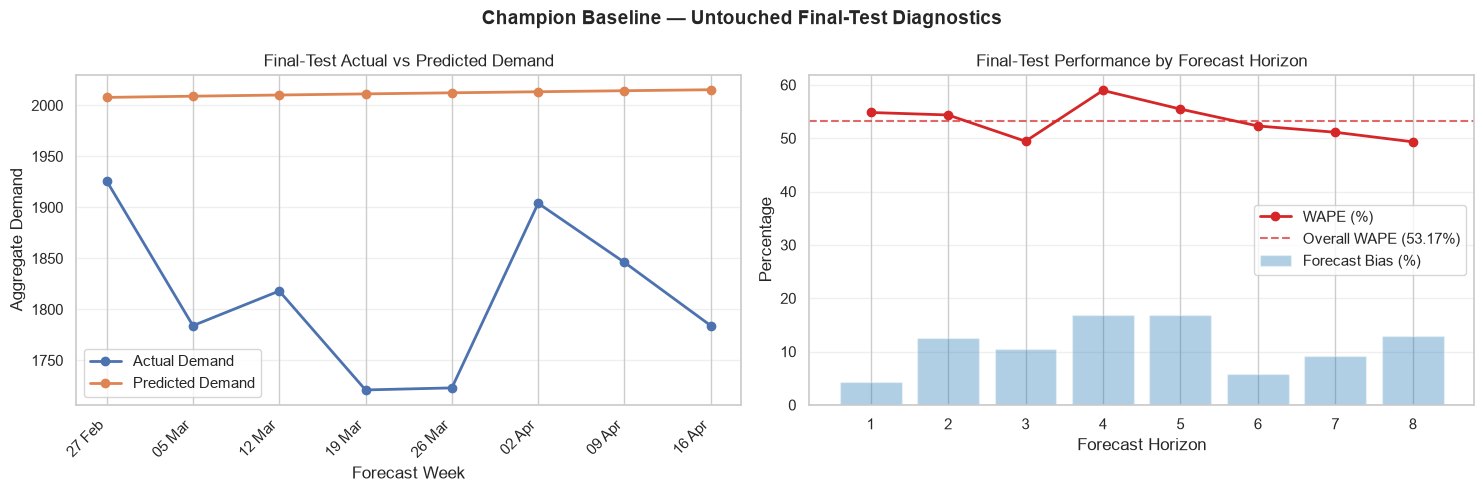

,Validation Control,Status
0,Champion configuration remains locked,PASS
1,Final-test forecasts remain locked,PASS
2,Scored dataset remains locked,PASS
3,Expected evaluation records retained,PASS
4,Unique series-week scoring key,PASS
5,All approved series retained,PASS
6,All eight horizons retained,PASS
7,Locked test boundary retained,PASS
8,Forecast origin precedes test period,PASS
9,Actual-demand totals reconcile,PASS


✅ Final-test evaluation validated: 14 of 14 controls passed.
🏁 Untouched final-test evaluation completed with WAPE 53.17% and Forecast Bias +10.94%.


In [27]:
# Visualise final-test diagnostics and validate evaluation integrity
if not champion_baseline_config.get(
    "final_test_metrics_calculated",
    False,
):
    raise ValueError(
        "Final-test metrics must be calculated before diagnostics."
    )

diagnostic_data = (
    final_test_horizon_metrics
    .sort_values("horizon")
    .reset_index(drop=True)
    .copy()
)

diagnostic_data["forecast_week"] = pd.to_datetime(
    diagnostic_data["forecast_week"]
)

horizon_positions = diagnostic_data["horizon"]
forecast_week_labels = (
    diagnostic_data["forecast_week"]
    .dt.strftime("%d %b")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

# Weekly aggregate demand comparison
axes[0].plot(
    horizon_positions,
    diagnostic_data["actual_demand"],
    marker="o",
    linewidth=2,
    label="Actual Demand",
)

axes[0].plot(
    horizon_positions,
    diagnostic_data["predicted_demand"],
    marker="o",
    linewidth=2,
    label="Predicted Demand",
)

axes[0].set_title(
    "Final-Test Actual vs Predicted Demand"
)
axes[0].set_xlabel("Forecast Week")
axes[0].set_ylabel("Aggregate Demand")
axes[0].set_xticks(horizon_positions)
axes[0].set_xticklabels(
    forecast_week_labels,
    rotation=45,
    ha="right",
)
axes[0].grid(
    axis="y",
    alpha=0.3,
)
axes[0].legend()

# Horizon-wise accuracy and directional bias
axes[1].plot(
    horizon_positions,
    diagnostic_data["wape_pct"],
    marker="o",
    linewidth=2,
    color="tab:red",
    label="WAPE (%)",
)

axes[1].bar(
    horizon_positions,
    diagnostic_data["bias_pct"],
    color="tab:blue",
    alpha=0.35,
    label="Forecast Bias (%)",
)

axes[1].axhline(
    final_test_wape_pct,
    color="tab:red",
    linestyle="--",
    alpha=0.7,
    label=f"Overall WAPE ({final_test_wape_pct:.2f}%)",
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[1].set_title(
    "Final-Test Performance by Forecast Horizon"
)
axes[1].set_xlabel("Forecast Horizon")
axes[1].set_ylabel("Percentage")
axes[1].set_xticks(horizon_positions)
axes[1].grid(
    axis="y",
    alpha=0.3,
)
axes[1].legend()

fig.suptitle(
    "Champion Baseline — Untouched Final-Test Diagnostics",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

evaluation_integrity_checks = {
    "Champion configuration remains locked": (
        champion_baseline_config[
            "configuration_status"
        ]
        == "LOCKED"
    ),
    "Final-test forecasts remain locked": (
        champion_baseline_config.get(
            "final_test_forecasts_locked",
            False,
        )
    ),
    "Scored dataset remains locked": (
        champion_baseline_config.get(
            "final_test_scored_dataset_locked",
            False,
        )
    ),
    "Expected evaluation records retained": (
        len(final_test_evaluation)
        == expected_scored_rows
    ),
    "Unique series-week scoring key": (
        not final_test_evaluation.duplicated(
            [SERIES_COLUMN, START_DATE_COLUMN]
        ).any()
    ),
    "All approved series retained": (
        final_test_evaluation[
            SERIES_COLUMN
        ].nunique()
        == expected_series_count
    ),
    "All eight horizons retained": (
        set(final_test_evaluation["horizon"])
        == set(range(1, FINAL_TEST_WEEKS + 1))
    ),
    "Locked test boundary retained": (
        pd.DatetimeIndex(
            final_test_evaluation[
                START_DATE_COLUMN
            ].unique()
        ).sort_values().equals(
            final_test_forecast_weeks.sort_values()
        )
    ),
    "Forecast origin precedes test period": (
        pd.to_datetime(
            final_test_evaluation["forecast_origin"]
        )
        < pd.to_datetime(
            final_test_evaluation[START_DATE_COLUMN]
        )
    ).all(),
    "Actual-demand totals reconcile": (
        np.isclose(
            diagnostic_data["actual_demand"].sum(),
            actual_demand_total,
        )
    ),
    "Predicted-demand totals reconcile": (
        np.isclose(
            diagnostic_data["predicted_demand"].sum(),
            predicted_demand_total,
        )
    ),
    "Stored WAPE reconciles": (
        np.isclose(
            champion_baseline_config[
                "final_test_wape_pct"
            ],
            final_test_wape_pct,
        )
    ),
    "Stored Forecast Bias reconciles": (
        np.isclose(
            champion_baseline_config[
                "final_test_bias_pct"
            ],
            final_test_bias_pct,
        )
    ),
    "Complete forecast coverage retained": (
        np.isclose(
            final_test_coverage_pct,
            100.0,
        )
    ),
}

final_test_validation_summary = pd.DataFrame({
    "Validation Control": list(
        evaluation_integrity_checks.keys()
    ),
    "Status": [
        "PASS" if passed else "FAIL"
        for passed in evaluation_integrity_checks.values()
    ],
})

display(final_test_validation_summary)

failed_checks = [
    check
    for check, passed
    in evaluation_integrity_checks.items()
    if not passed
]

if failed_checks:
    raise ValueError(
        "Final-test evaluation validation failed: "
        f"{failed_checks}"
    )

champion_baseline_config.update({
    "final_test_evaluation_validated": True,
    "final_test_evaluation_status": "COMPLETED",
})

print(
    "✅ Final-test evaluation validated: "
    f"{len(evaluation_integrity_checks)} of "
    f"{len(evaluation_integrity_checks)} controls passed."
)
print(
    "🏁 Untouched final-test evaluation completed "
    f"with WAPE {final_test_wape_pct:.2f}% and "
    f"Forecast Bias {final_test_bias_pct:+.2f}%."
)

#### ✅ Final-Test Evaluation Summary

The champion achieved a final-test **WAPE of 53.17%**, compared with **50.02%** during validation—a deterioration of **3.16 percentage points**.

> **Rounding note:** The deterioration of **3.16 percentage points** is calculated from the underlying unrounded WAPE values. Subtracting the displayed rounded values gives **3.15 percentage points**.

Forecast Bias increased from **+0.21%** during validation to **+10.94%** on the final test. Positive bias across all eight forecast horizons indicates a consistent tendency to over-forecast demand. Horizon-wise WAPE ranged from **49.32% to 58.95%**.

All **14 evaluation-integrity controls** passed. These results therefore form the unbiased baseline benchmark, and no further tuning is permitted using final-test evidence.

#### 🏁 Section 5 Completion

Section 5 has established the approved baseline benchmark through validation-based champion selection and one-time holdout evaluation.

The next section will persist the resulting artefacts, verify their reproducibility and prepare the Notebook 05 handoff.


---

## 💾 6. Outputs, Conclusion and Notebook 05 Handoff

This section converts the validated Notebook 04 results into reusable outputs and completes the baseline-modelling handoff to Notebook 05.

### 6.1 Export and Validate Outputs

The following machine-readable handoff artefacts will be exported to `data/processed/baseline_outputs`:

* `04_baseline_forecasts.csv`
* `04_baseline_model_metrics.csv`
* `04_baseline_sku_metrics.csv`
* `04_champion_baseline_config.json`

The following reporting tables will be saved to `reports/tables`:

* `04_baseline_selection_scorecard.csv`
* `04_baseline_validation_fold_metrics.csv`
* `04_baseline_validation_horizon_metrics.csv`
* `04_baseline_final_test_overall_metrics.csv`
* `04_baseline_final_test_horizon_metrics.csv`
* `04_baseline_final_test_validation_summary.csv`

The champion diagnostic figure will be saved as `reports/figures/04_baseline_champion_final_test_diagnostics.png`.

A reload-based validation will verify file availability, required schemas, unique forecast keys, series and horizon coverage, metric reconciliation, and consistency with the locked champion configuration.

In [28]:
# Prepare baseline handoff datasets and export locations

required_export_objects = [
    "PROJECT_ROOT",
    "baseline_scored_forecasts",
    "baseline_selection_scorecard",
    "final_test_evaluation",
    "champion_baseline_config",
]

missing_export_objects = [
    object_name
    for object_name in required_export_objects
    if object_name not in globals()
]

if missing_export_objects:
    raise NameError(
        "Required export objects are missing: "
        f"{missing_export_objects}"
    )

if not champion_baseline_config.get(
    "final_test_evaluation_validated",
    False,
):
    raise ValueError(
        "Validated final-test evaluation is required before export."
    )

# Define dedicated output locations
baseline_output_dir = (
    Path(PROJECT_ROOT)
    / "data"
    / "processed"
    / "baseline_outputs"
)

table_output_dir = (
    Path(PROJECT_ROOT)
    / "reports"
    / "tables"
)

figure_output_dir = (
    Path(PROJECT_ROOT)
    / "reports"
    / "figures"
)

for output_dir in [
    baseline_output_dir,
    table_output_dir,
    figure_output_dir,
]:
    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

required_forecast_columns = [
    "candidate",
    "split_id",
    "forecast_origin",
    "horizon",
    SERIES_COLUMN,
    START_DATE_COLUMN,
    "actual_demand",
    "predicted_demand",
]

forecast_schema_checks = {
    "Validation forecast schema": set(
        required_forecast_columns
    ).issubset(
        baseline_scored_forecasts.columns
    ),
    "Final-test forecast schema": set(
        required_forecast_columns
    ).issubset(
        final_test_evaluation.columns
    ),
}

if not all(forecast_schema_checks.values()):
    failed_checks = [
        check
        for check, passed
        in forecast_schema_checks.items()
        if not passed
    ]

    raise ValueError(
        "Forecast export schema validation failed: "
        f"{failed_checks}"
    )


def prepare_forecast_records(
    forecast_data,
    evaluation_stage,
):
    """Standardise forecast records for the baseline handoff."""

    prepared_data = forecast_data[
        required_forecast_columns
    ].copy()

    prepared_data.insert(
        0,
        "evaluation_stage",
        evaluation_stage,
    )

    prepared_data["forecast_origin"] = pd.to_datetime(
        prepared_data["forecast_origin"]
    )

    prepared_data[START_DATE_COLUMN] = pd.to_datetime(
        prepared_data[START_DATE_COLUMN]
    )

    prepared_data["actual_demand"] = pd.to_numeric(
        prepared_data["actual_demand"],
        errors="raise",
    )

    prepared_data["predicted_demand"] = pd.to_numeric(
        prepared_data["predicted_demand"],
        errors="raise",
    )

    prepared_data["forecast_error"] = (
        prepared_data["predicted_demand"]
        - prepared_data["actual_demand"]
    )

    prepared_data["absolute_error"] = (
        prepared_data["forecast_error"].abs()
    )

    prepared_data["squared_error"] = (
        prepared_data["forecast_error"] ** 2
    )

    return prepared_data


validation_forecasts_export = prepare_forecast_records(
    forecast_data=baseline_scored_forecasts,
    evaluation_stage="rolling_validation",
)

final_test_forecasts_export = prepare_forecast_records(
    forecast_data=final_test_evaluation,
    evaluation_stage="final_test",
)

baseline_forecasts_export = (
    pd.concat(
        [
            validation_forecasts_export,
            final_test_forecasts_export,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "evaluation_stage",
            "candidate",
            "split_id",
            SERIES_COLUMN,
            "horizon",
        ]
    )
    .reset_index(drop=True)
)

# Preserve the validation model-selection scorecard
baseline_model_metrics_export = (
    baseline_selection_scorecard.copy()
    .reset_index(drop=True)
)

# Calculate comparable SKU-store metrics
baseline_sku_metrics_export = (
    baseline_forecasts_export.groupby(
        [
            "evaluation_stage",
            "candidate",
            SERIES_COLUMN,
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        forecast_records=(
            "predicted_demand",
            "size",
        ),
        actual_demand_total=(
            "actual_demand",
            "sum",
        ),
        predicted_demand_total=(
            "predicted_demand",
            "sum",
        ),
        absolute_error_total=(
            "absolute_error",
            "sum",
        ),
        squared_error_total=(
            "squared_error",
            "sum",
        ),
        forecast_error_total=(
            "forecast_error",
            "sum",
        ),
    )
)

positive_actual_mask = (
    baseline_sku_metrics_export[
        "actual_demand_total"
    ] > 0
)

baseline_sku_metrics_export["wape_pct"] = np.where(
    positive_actual_mask,
    (
        baseline_sku_metrics_export[
            "absolute_error_total"
        ]
        / baseline_sku_metrics_export[
            "actual_demand_total"
        ]
        * 100
    ),
    np.nan,
)

baseline_sku_metrics_export["bias_pct"] = np.where(
    positive_actual_mask,
    (
        baseline_sku_metrics_export[
            "forecast_error_total"
        ]
        / baseline_sku_metrics_export[
            "actual_demand_total"
        ]
        * 100
    ),
    np.nan,
)

baseline_sku_metrics_export["mae"] = (
    baseline_sku_metrics_export[
        "absolute_error_total"
    ]
    / baseline_sku_metrics_export[
        "forecast_records"
    ]
)

baseline_sku_metrics_export["rmse"] = np.sqrt(
    baseline_sku_metrics_export[
        "squared_error_total"
    ]
    / baseline_sku_metrics_export[
        "forecast_records"
    ]
)

baseline_sku_metrics_export = (
    baseline_sku_metrics_export.sort_values(
        [
            "evaluation_stage",
            "candidate",
            SERIES_COLUMN,
        ]
    )
    .reset_index(drop=True)
)

expected_combined_forecast_rows = (
    len(baseline_scored_forecasts)
    + len(final_test_evaluation)
)

export_preparation_checks = {
    "Expected combined forecast records": (
        len(baseline_forecasts_export)
        == expected_combined_forecast_rows
    ),
    "Unique forecast keys": (
        not baseline_forecasts_export.duplicated(
            [
                "evaluation_stage",
                "candidate",
                "split_id",
                SERIES_COLUMN,
                START_DATE_COLUMN,
            ]
        ).any()
    ),
    "Forecast values complete": (
        baseline_forecasts_export[
            "predicted_demand"
        ].notna().all()
    ),
    "Actual values complete": (
        baseline_forecasts_export[
            "actual_demand"
        ].notna().all()
    ),
    "Validation records retained": (
        len(validation_forecasts_export)
        == len(baseline_scored_forecasts)
    ),
    "Final-test records retained": (
        len(final_test_forecasts_export)
        == expected_scored_rows
    ),
    "Model metrics available": (
        not baseline_model_metrics_export.empty
    ),
    "SKU-store metrics available": (
        not baseline_sku_metrics_export.empty
    ),
}

if not all(export_preparation_checks.values()):
    failed_checks = [
        check
        for check, passed
        in export_preparation_checks.items()
        if not passed
    ]

    raise ValueError(
        "Baseline export preparation failed: "
        f"{failed_checks}"
    )

export_preparation_summary = pd.DataFrame({
    "Prepared Artefact": [
        "04_baseline_forecasts.csv",
        "04_baseline_model_metrics.csv",
        "04_baseline_sku_metrics.csv",
        "04_champion_baseline_config.json",
    ],
    "Prepared Records": [
        len(baseline_forecasts_export),
        len(baseline_model_metrics_export),
        len(baseline_sku_metrics_export),
        1,
    ],
    "Status": [
        "READY",
        "READY",
        "READY",
        "READY",
    ],
})

display(export_preparation_summary)

print(
    "✅ Baseline handoff datasets prepared and "
    "validated successfully."
)

baseline_output_display = (
    baseline_output_dir
    .relative_to(Path(PROJECT_ROOT))
    .as_posix()
)

print(
    "📁 Baseline output location: "
    f"{baseline_output_display}"
)

,Prepared Artefact,Prepared Records,Status
0,04_baseline_forecasts.csv,52800,READY
1,04_baseline_model_metrics.csv,7,READY
2,04_baseline_sku_metrics.csv,2400,READY
3,04_champion_baseline_config.json,1,READY


✅ Baseline handoff datasets prepared and validated successfully.
📁 Baseline output location: data/processed/baseline_outputs


In [29]:
# Export Notebook 04 baseline outputs using the standard 04_ prefix

required_write_objects = [
    "baseline_forecasts_export",
    "baseline_model_metrics_export",
    "baseline_sku_metrics_export",
    "baseline_selection_scorecard",
    "validation_forecasts_export",
    "final_test_overall_metrics",
    "final_test_horizon_summary",
    "final_test_validation_summary",
    "champion_baseline_config",
    "baseline_output_dir",
    "table_output_dir",
    "figure_output_dir",
    "fig",
]

missing_write_objects = [
    object_name
    for object_name in required_write_objects
    if object_name not in globals()
]

if missing_write_objects:
    raise NameError(
        "Required export objects are missing: "
        f"{missing_write_objects}"
    )


def build_validation_report(
    forecast_data,
    group_columns,
):
    """Calculate compact validation metrics by selected groups."""

    validation_summary = (
        forecast_data.groupby(
            group_columns,
            as_index=False,
            dropna=False,
        )
        .agg(
            records=(
                "predicted_demand",
                "size",
            ),
            actual_demand_total=(
                "actual_demand",
                "sum",
            ),
            predicted_demand_total=(
                "predicted_demand",
                "sum",
            ),
            absolute_error_total=(
                "absolute_error",
                "sum",
            ),
            squared_error_total=(
                "squared_error",
                "sum",
            ),
            forecast_error_total=(
                "forecast_error",
                "sum",
            ),
        )
    )

    if (
        validation_summary["actual_demand_total"] <= 0
    ).any():
        raise ValueError(
            "Positive aggregate actual demand is required "
            "for validation reporting metrics."
        )

    validation_summary["wape_pct"] = (
        validation_summary["absolute_error_total"]
        / validation_summary["actual_demand_total"]
        * 100
    )

    validation_summary["bias_pct"] = (
        validation_summary["forecast_error_total"]
        / validation_summary["actual_demand_total"]
        * 100
    )

    validation_summary["mae"] = (
        validation_summary["absolute_error_total"]
        / validation_summary["records"]
    )

    validation_summary["rmse"] = np.sqrt(
        validation_summary["squared_error_total"]
        / validation_summary["records"]
    )

    return validation_summary.round({
        "actual_demand_total": 2,
        "predicted_demand_total": 2,
        "absolute_error_total": 2,
        "squared_error_total": 2,
        "forecast_error_total": 2,
        "wape_pct": 2,
        "bias_pct": 2,
        "mae": 4,
        "rmse": 4,
    })


# Prepare compact rolling-validation reporting tables
validation_fold_metrics_export = (
    build_validation_report(
        forecast_data=validation_forecasts_export,
        group_columns=[
            "candidate",
            "split_id",
            "forecast_origin",
        ],
    )
    .sort_values(
        ["candidate", "split_id"]
    )
    .reset_index(drop=True)
)

validation_horizon_metrics_export = (
    build_validation_report(
        forecast_data=validation_forecasts_export,
        group_columns=[
            "candidate",
            "horizon",
        ],
    )
    .sort_values(
        ["candidate", "horizon"]
    )
    .reset_index(drop=True)
)

# Define Notebook 04 handoff paths
baseline_handoff_paths = {
    "04_baseline_forecasts.csv": (
        baseline_output_dir
        / "04_baseline_forecasts.csv"
    ),
    "04_baseline_model_metrics.csv": (
        baseline_output_dir
        / "04_baseline_model_metrics.csv"
    ),
    "04_baseline_sku_metrics.csv": (
        baseline_output_dir
        / "04_baseline_sku_metrics.csv"
    ),
    "04_champion_baseline_config.json": (
        baseline_output_dir
        / "04_champion_baseline_config.json"
    ),
}

# Define Notebook 04 reporting-table paths
baseline_report_table_paths = {
    "04_baseline_selection_scorecard.csv": (
        table_output_dir
        / "04_baseline_selection_scorecard.csv"
    ),
    "04_baseline_validation_fold_metrics.csv": (
        table_output_dir
        / "04_baseline_validation_fold_metrics.csv"
    ),
    "04_baseline_validation_horizon_metrics.csv": (
        table_output_dir
        / "04_baseline_validation_horizon_metrics.csv"
    ),
    "04_baseline_final_test_overall_metrics.csv": (
        table_output_dir
        / "04_baseline_final_test_overall_metrics.csv"
    ),
    "04_baseline_final_test_horizon_metrics.csv": (
        table_output_dir
        / "04_baseline_final_test_horizon_metrics.csv"
    ),
    "04_baseline_final_test_validation_summary.csv": (
        table_output_dir
        / "04_baseline_final_test_validation_summary.csv"
    ),
}

# Define the Notebook 04 diagnostic-figure path
champion_diagnostic_path = (
    figure_output_dir
    / "04_baseline_champion_final_test_diagnostics.png"
)

# Prepare the three tabular handoff datasets
handoff_tables = {
    "04_baseline_forecasts.csv": (
        baseline_forecasts_export
    ),
    "04_baseline_model_metrics.csv": (
        baseline_model_metrics_export
    ),
    "04_baseline_sku_metrics.csv": (
        baseline_sku_metrics_export
    ),
}

# Export the handoff datasets
for file_name, export_data in handoff_tables.items():
    export_data.to_csv(
        baseline_handoff_paths[file_name],
        index=False,
        encoding="utf-8",
    )


def make_json_safe(value):
    """Convert common pandas and NumPy values for JSON export."""

    if value is None:
        return None

    if isinstance(value, np.generic):
        return make_json_safe(value.item())

    if isinstance(value, float):
        return value if np.isfinite(value) else None

    if isinstance(value, (str, int, bool)):
        return value

    if isinstance(value, (pd.Timestamp, np.datetime64)):
        if pd.isna(value):
            return None
        return pd.Timestamp(value).isoformat()

    if isinstance(value, (pd.Timedelta, np.timedelta64)):
        return str(value)

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(
        value,
        (list, tuple, set, np.ndarray, pd.Index),
    ):
        return [
            make_json_safe(item)
            for item in value
        ]

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    raise TypeError(
        "Unsupported configuration value type: "
        f"{type(value).__name__}"
    )


# Prepare and export the champion configuration
champion_config_export = dict(
    champion_baseline_config
)

champion_config_export.update({
    "export_status": "COMPLETED",
    "handoff_files": list(
        baseline_handoff_paths.keys()
    ),
    "reporting_tables": list(
        baseline_report_table_paths.keys()
    ),
    "diagnostic_figure": (
        champion_diagnostic_path.name
    ),
})

champion_config_export = make_json_safe(
    champion_config_export
)

with open(
    baseline_handoff_paths[
        "04_champion_baseline_config.json"
    ],
    "w",
    encoding="utf-8",
) as config_file:
    json.dump(
        champion_config_export,
        config_file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )

# Prepare and export the reporting tables
report_tables = {
    "04_baseline_selection_scorecard.csv": (
        baseline_selection_scorecard
    ),
    "04_baseline_validation_fold_metrics.csv": (
        validation_fold_metrics_export
    ),
    "04_baseline_validation_horizon_metrics.csv": (
        validation_horizon_metrics_export
    ),
    "04_baseline_final_test_overall_metrics.csv": (
        final_test_overall_metrics
    ),
    "04_baseline_final_test_horizon_metrics.csv": (
        final_test_horizon_summary
    ),
    "04_baseline_final_test_validation_summary.csv": (
        final_test_validation_summary
    ),
}

for file_name, export_data in report_tables.items():
    export_data.to_csv(
        baseline_report_table_paths[file_name],
        index=False,
        encoding="utf-8",
    )

# Save the Notebook 04 diagnostic figure
fig.savefig(
    champion_diagnostic_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Create the new export manifest
export_manifest_records = []

for file_name, export_data in handoff_tables.items():
    file_path = baseline_handoff_paths[file_name]

    export_manifest_records.append({
        "Output Type": "Handoff Dataset",
        "File": file_name,
        "Records": len(export_data),
        "Location": file_path.relative_to(
            Path(PROJECT_ROOT)
        ).as_posix(),
        "Status": (
            "WRITTEN"
            if file_path.is_file()
            and file_path.stat().st_size > 0
            else "FAILED"
        ),
    })

config_path = baseline_handoff_paths[
    "04_champion_baseline_config.json"
]

export_manifest_records.append({
    "Output Type": "Configuration",
    "File": config_path.name,
    "Records": 1,
    "Location": config_path.relative_to(
        Path(PROJECT_ROOT)
    ).as_posix(),
    "Status": (
        "WRITTEN"
        if config_path.is_file()
        and config_path.stat().st_size > 0
        else "FAILED"
    ),
})

for file_name, export_data in report_tables.items():
    file_path = baseline_report_table_paths[
        file_name
    ]

    export_manifest_records.append({
        "Output Type": "Reporting Table",
        "File": file_name,
        "Records": len(export_data),
        "Location": file_path.relative_to(
            Path(PROJECT_ROOT)
        ).as_posix(),
        "Status": (
            "WRITTEN"
            if file_path.is_file()
            and file_path.stat().st_size > 0
            else "FAILED"
        ),
    })

export_manifest_records.append({
    "Output Type": "Diagnostic Figure",
    "File": champion_diagnostic_path.name,
    "Records": 1,
    "Location": champion_diagnostic_path.relative_to(
        Path(PROJECT_ROOT)
    ).as_posix(),
    "Status": (
        "WRITTEN"
        if champion_diagnostic_path.is_file()
        and champion_diagnostic_path.stat().st_size > 0
        else "FAILED"
    ),
})

export_manifest = pd.DataFrame(
    export_manifest_records
)

# Prepare a compact PDF-safe display
export_manifest_display = (
    export_manifest[
        [
            "Output Type",
            "File",
            "Records",
            "Status",
        ]
    ]
    .rename(columns={
        "Output Type": "Type",
        "File": "Artefact",
    })
)

display(export_manifest_display)

if not export_manifest["Status"].eq(
    "WRITTEN"
).all():
    failed_files = export_manifest.loc[
        export_manifest["Status"].ne("WRITTEN"),
        "File",
    ].tolist()

    raise IOError(
        "Notebook 04 export failed for: "
        f"{failed_files}"
    )

# Define only the exact obsolete Notebook 04 paths
obsolete_notebook_04_paths = [
    baseline_output_dir
    / "baseline_forecasts.csv",
    baseline_output_dir
    / "baseline_model_metrics.csv",
    baseline_output_dir
    / "baseline_sku_metrics.csv",
    baseline_output_dir
    / "champion_baseline_config.json",
    table_output_dir
    / "04_4_baseline_selection_scorecard.csv",
    table_output_dir
    / "04_4_validation_fold_metrics.csv",
    table_output_dir
    / "04_4_validation_horizon_metrics.csv",
    table_output_dir
    / "05_2_final_test_overall_metrics.csv",
    table_output_dir
    / "05_2_final_test_horizon_metrics.csv",
    table_output_dir
    / "05_2_final_test_validation_summary.csv",
    figure_output_dir
    / "05_2_champion_final_test_diagnostics.png",
]

new_notebook_04_paths = [
    *baseline_handoff_paths.values(),
    *baseline_report_table_paths.values(),
    champion_diagnostic_path,
]

if set(obsolete_notebook_04_paths).intersection(
    new_notebook_04_paths
):
    raise ValueError(
        "Cleanup stopped because an obsolete path "
        "overlaps with a new Notebook 04 output."
    )

# Remove obsolete names only after all new outputs pass
removed_obsolete_files = []

for obsolete_path in obsolete_notebook_04_paths:
    if obsolete_path.is_file():
        obsolete_path.unlink()
        removed_obsolete_files.append(
            obsolete_path.name
        )

if any(
    obsolete_path.exists()
    for obsolete_path in obsolete_notebook_04_paths
):
    raise IOError(
        "One or more obsolete Notebook 04 files "
        "could not be removed."
    )

# Prepare portable project-relative paths for display
baseline_output_display = (
    baseline_output_dir
    .relative_to(Path(PROJECT_ROOT))
    .as_posix()
)

table_output_display = (
    table_output_dir
    .relative_to(Path(PROJECT_ROOT))
    .as_posix()
)

champion_diagnostic_display = (
    champion_diagnostic_path
    .relative_to(Path(PROJECT_ROOT))
    .as_posix()
)

print(
    "✅ Notebook 04 exports completed: "
    f"{len(export_manifest)} of "
    f"{len(export_manifest)} files written successfully."
)
print(
    "🧹 Obsolete Notebook 04 files removed: "
    f"{len(removed_obsolete_files)}."
)
print(
    "📦 Handoff artefacts: "
    f"{baseline_output_display}"
)
print(
    "📊 Reporting tables: "
    f"{table_output_display}"
)
print(
    "🖼️ Diagnostic figure: "
    f"{champion_diagnostic_display}"
)

,Type,Artefact,Records,Status
0,Handoff Dataset,04_baseline_forecasts.csv,52800,WRITTEN
1,Handoff Dataset,04_baseline_model_metrics.csv,7,WRITTEN
2,Handoff Dataset,04_baseline_sku_metrics.csv,2400,WRITTEN
3,Configuration,04_champion_baseline_config.json,1,WRITTEN
4,Reporting Table,04_baseline_selection_scorecard.csv,7,WRITTEN
5,Reporting Table,04_baseline_validation_fold_metrics.csv,21,WRITTEN
6,Reporting Table,04_baseline_validation_horizon_metrics.csv,56,WRITTEN
7,Reporting Table,04_baseline_final_test_overall_metrics.csv,7,WRITTEN
8,Reporting Table,04_baseline_final_test_horizon_metrics.csv,8,WRITTEN
9,Reporting Table,04_baseline_final_test_validation_summary.csv,14,WRITTEN


✅ Notebook 04 exports completed: 11 of 11 files written successfully.
🧹 Obsolete Notebook 04 files removed: 0.
📦 Handoff artefacts: data/processed/baseline_outputs
📊 Reporting tables: reports/tables
🖼️ Diagnostic figure: reports/figures/04_baseline_champion_final_test_diagnostics.png


In [30]:
# Reload and validate all Notebook 04 baseline outputs
import json

required_reload_objects = [
    "baseline_forecasts_export",
    "baseline_model_metrics_export",
    "baseline_sku_metrics_export",
    "validation_forecasts_export",
    "baseline_handoff_paths",
    "baseline_report_table_paths",
    "report_tables",
    "champion_diagnostic_path",
    "champion_baseline_config",
    "required_forecast_columns",
    "SERIES_COLUMN",
    "START_DATE_COLUMN",
    "FINAL_TEST_WEEKS",
    "final_test_wape_pct",
    "final_test_bias_pct",
    "final_test_mae",
    "final_test_rmse",
    "final_test_coverage_pct",
]

missing_reload_objects = [
    object_name
    for object_name in required_reload_objects
    if object_name not in globals()
]

if missing_reload_objects:
    raise NameError(
        "Required reload-validation objects are missing: "
        f"{missing_reload_objects}"
    )


# Define the complete Notebook 04 output inventory
all_export_paths = [
    *baseline_handoff_paths.values(),
    *baseline_report_table_paths.values(),
    champion_diagnostic_path,
]

file_availability_checks = {
    file_path.name: (
        file_path.is_file()
        and file_path.stat().st_size > 0
    )
    for file_path in all_export_paths
}

missing_or_empty_files = [
    file_name
    for file_name, is_available
    in file_availability_checks.items()
    if not is_available
]

if missing_or_empty_files:
    raise FileNotFoundError(
        "Notebook 04 output files are missing or empty: "
        f"{missing_or_empty_files}"
    )


# Reload the three baseline handoff datasets
reloaded_baseline_forecasts = pd.read_csv(
    baseline_handoff_paths[
        "04_baseline_forecasts.csv"
    ],
    parse_dates=[
        "forecast_origin",
        START_DATE_COLUMN,
    ],
)

reloaded_baseline_model_metrics = pd.read_csv(
    baseline_handoff_paths[
        "04_baseline_model_metrics.csv"
    ]
)

reloaded_baseline_sku_metrics = pd.read_csv(
    baseline_handoff_paths[
        "04_baseline_sku_metrics.csv"
    ]
)


# Reload the champion baseline configuration
with open(
    baseline_handoff_paths[
        "04_champion_baseline_config.json"
    ],
    "r",
    encoding="utf-8",
) as config_file:
    reloaded_champion_config = json.load(
        config_file
    )


# Reload all six reporting tables
reloaded_report_tables = {
    file_name: pd.read_csv(file_path)
    for file_name, file_path
    in baseline_report_table_paths.items()
}


# Confirm that the diagnostic figure is readable
try:
    reloaded_diagnostic_figure = plt.imread(
        champion_diagnostic_path
    )

    diagnostic_figure_readable = (
        reloaded_diagnostic_figure.size > 0
    )

except Exception:
    diagnostic_figure_readable = False


def dataframes_reconcile(
    expected_data,
    reloaded_data,
    datetime_columns=None,
    string_columns=None,
):
    """
    Compare an in-memory DataFrame with its reloaded
    exported version after normalising compatible types.
    """

    datetime_columns = datetime_columns or []
    string_columns = string_columns or []

    expected = (
        expected_data.copy()
        .reset_index(drop=True)
    )

    reloaded = (
        reloaded_data.copy()
        .reset_index(drop=True)
    )

    if list(expected.columns) != list(
        reloaded.columns
    ):
        return False

    if len(expected) != len(reloaded):
        return False

    for column in datetime_columns:
        if (
            column not in expected.columns
            or column not in reloaded.columns
        ):
            return False

        expected[column] = pd.to_datetime(
            expected[column],
            errors="coerce",
        )

        reloaded[column] = pd.to_datetime(
            reloaded[column],
            errors="coerce",
        )

    for column in expected.columns:
        if column in datetime_columns:
            continue

        if column in string_columns:
            expected[column] = (
                expected[column]
                .astype("string")
                .fillna("<MISSING>")
            )

            reloaded[column] = (
                reloaded[column]
                .astype("string")
                .fillna("<MISSING>")
            )

        elif (
            pd.api.types.is_numeric_dtype(
                expected[column]
            )
            or pd.api.types.is_numeric_dtype(
                reloaded[column]
            )
        ):
            try:
                expected[column] = pd.to_numeric(
                    expected[column],
                    errors="coerce",
                )

                reloaded[column] = pd.to_numeric(
                    reloaded[column],
                    errors="coerce",
                )

            except (TypeError, ValueError):
                return False

        else:
            expected[column] = (
                expected[column]
                .astype("string")
                .fillna("<MISSING>")
            )

            reloaded[column] = (
                reloaded[column]
                .astype("string")
                .fillna("<MISSING>")
            )

    try:
        pd.testing.assert_frame_equal(
            expected,
            reloaded,
            check_dtype=False,
            check_exact=False,
            rtol=1e-7,
            atol=1e-9,
        )

        return True

    except AssertionError:
        return False


# Reconcile the complete baseline forecast dataset
forecast_values_reconcile = dataframes_reconcile(
    expected_data=baseline_forecasts_export,
    reloaded_data=reloaded_baseline_forecasts,
    datetime_columns=[
        "forecast_origin",
        START_DATE_COLUMN,
    ],
    string_columns=[
        "evaluation_stage",
        "candidate",
        "split_id",
        SERIES_COLUMN,
    ],
)


# Reconcile model-level metrics
model_metrics_reconcile = dataframes_reconcile(
    expected_data=baseline_model_metrics_export,
    reloaded_data=(
        reloaded_baseline_model_metrics
    ),
)


# Reconcile SKU-store-level metrics
sku_metrics_reconcile = dataframes_reconcile(
    expected_data=baseline_sku_metrics_export,
    reloaded_data=reloaded_baseline_sku_metrics,
    string_columns=[
        "evaluation_stage",
        "candidate",
        SERIES_COLUMN,
    ],
)


# Reconcile all six reporting tables
report_table_reconciliation = {}

for file_name, expected_table in report_tables.items():
    datetime_columns = (
        ["forecast_origin"]
        if "forecast_origin"
        in expected_table.columns
        else []
    )

    string_columns = [
        column
        for column in [
            "candidate",
            "split_id",
        ]
        if column in expected_table.columns
    ]

    report_table_reconciliation[file_name] = (
        dataframes_reconcile(
            expected_data=expected_table,
            reloaded_data=(
                reloaded_report_tables[file_name]
            ),
            datetime_columns=datetime_columns,
            string_columns=string_columns,
        )
    )

all_reporting_tables_reconcile = all(
    report_table_reconciliation.values()
)


# Define the expected reloaded forecast schema
expected_reloaded_forecast_columns = [
    "evaluation_stage",
    *required_forecast_columns,
    "forecast_error",
    "absolute_error",
    "squared_error",
]


# Separate the two evaluation stages
reloaded_final_test_forecasts = (
    reloaded_baseline_forecasts.loc[
        reloaded_baseline_forecasts[
            "evaluation_stage"
        ].eq("final_test")
    ].copy()
)

reloaded_validation_forecasts = (
    reloaded_baseline_forecasts.loc[
        reloaded_baseline_forecasts[
            "evaluation_stage"
        ].eq("rolling_validation")
    ].copy()
)


# Derive expected coverage directly from the exported data
expected_combined_forecast_rows = len(
    baseline_forecasts_export
)

expected_scored_rows = (
    baseline_forecasts_export[
        "evaluation_stage"
    ]
    .eq("final_test")
    .sum()
)

expected_series_count = (
    baseline_forecasts_export.loc[
        baseline_forecasts_export[
            "evaluation_stage"
        ].eq("final_test"),
        SERIES_COLUMN,
    ]
    .nunique()
)


# Recalculate final-test metrics from reloaded forecasts
reloaded_final_actual_total = (
    reloaded_final_test_forecasts[
        "actual_demand"
    ].sum()
)

if reloaded_final_actual_total <= 0:
    raise ValueError(
        "Positive final-test actual demand is required "
        "for metric reconciliation."
    )

reloaded_final_wape_pct = (
    reloaded_final_test_forecasts[
        "absolute_error"
    ].sum()
    / reloaded_final_actual_total
    * 100
)

reloaded_final_bias_pct = (
    reloaded_final_test_forecasts[
        "forecast_error"
    ].sum()
    / reloaded_final_actual_total
    * 100
)

reloaded_final_mae = (
    reloaded_final_test_forecasts[
        "absolute_error"
    ].mean()
)

reloaded_final_rmse = np.sqrt(
    reloaded_final_test_forecasts[
        "squared_error"
    ].mean()
)

reloaded_final_coverage_pct = (
    reloaded_final_test_forecasts[
        "predicted_demand"
    ].notna().mean()
    * 100
)


# Validate the stored final-test configuration metrics
configuration_metric_reference = {
    "final_test_wape_pct": (
        final_test_wape_pct
    ),
    "final_test_bias_pct": (
        final_test_bias_pct
    ),
    "final_test_mae": (
        final_test_mae
    ),
    "final_test_rmse": (
        final_test_rmse
    ),
    "final_test_coverage_pct": (
        final_test_coverage_pct
    ),
}

configuration_metrics_reconcile = all(
    metric_name in reloaded_champion_config
    and np.isclose(
        float(
            reloaded_champion_config[
                metric_name
            ]
        ),
        reference_value,
    )
    for metric_name, reference_value
    in configuration_metric_reference.items()
)


# Execute the complete reload-validation audit
reload_validation_checks = {
    "All 11 exported files are available": (
        len(all_export_paths) == 11
        and all(
            file_availability_checks.values()
        )
    ),
    "Forecast record count retained": (
        len(reloaded_baseline_forecasts)
        == expected_combined_forecast_rows
    ),
    "Model metric record count retained": (
        len(reloaded_baseline_model_metrics)
        == len(baseline_model_metrics_export)
    ),
    "SKU-store metric record count retained": (
        len(reloaded_baseline_sku_metrics)
        == len(baseline_sku_metrics_export)
    ),
    "Forecast schema retained": (
        list(
            reloaded_baseline_forecasts.columns
        )
        == expected_reloaded_forecast_columns
    ),
    "Unique forecast keys retained": (
        not reloaded_baseline_forecasts.duplicated(
            [
                "evaluation_stage",
                "candidate",
                "split_id",
                SERIES_COLUMN,
                START_DATE_COLUMN,
            ]
        ).any()
    ),
    "Forecast values remain complete": (
        reloaded_baseline_forecasts[
            [
                "actual_demand",
                "predicted_demand",
            ]
        ].notna().all().all()
    ),
    "Evaluation stages retained": (
        set(
            reloaded_baseline_forecasts[
                "evaluation_stage"
            ]
        )
        == {
            "rolling_validation",
            "final_test",
        }
    ),
    "Validation forecast coverage retained": (
        len(reloaded_validation_forecasts)
        == len(validation_forecasts_export)
    ),
    "Final-test forecast coverage retained": (
        len(reloaded_final_test_forecasts)
        == expected_scored_rows
    ),
    "Final-test series coverage retained": (
        reloaded_final_test_forecasts[
            SERIES_COLUMN
        ].nunique()
        == expected_series_count
    ),
    "Final-test horizon coverage retained": (
        set(
            reloaded_final_test_forecasts[
                "horizon"
            ]
        )
        == set(
            range(1, FINAL_TEST_WEEKS + 1)
        )
    ),
    "Forecast chronology retained": (
        (
            reloaded_baseline_forecasts[
                "forecast_origin"
            ]
            < reloaded_baseline_forecasts[
                START_DATE_COLUMN
            ]
        ).all()
    ),
    "Forecast dataset values reconcile": (
        forecast_values_reconcile
    ),
    "Model metric values reconcile": (
        model_metrics_reconcile
    ),
    "Unique SKU-store metric keys retained": (
        not reloaded_baseline_sku_metrics.duplicated(
            [
                "evaluation_stage",
                "candidate",
                SERIES_COLUMN,
            ]
        ).any()
    ),
    "SKU-store metric values reconcile": (
        sku_metrics_reconcile
    ),
    "All reporting-table values reconcile": (
        all_reporting_tables_reconcile
    ),
    "Champion configuration remains locked": (
        reloaded_champion_config.get(
            "configuration_status"
        )
        == "LOCKED"
    ),
    "Final-test completion status retained": (
        reloaded_champion_config.get(
            "final_test_evaluation_validated"
        )
        is True
        and reloaded_champion_config.get(
            "final_test_evaluation_status"
        )
        == "COMPLETED"
    ),
    "Configuration file inventory retained": (
        set(
            reloaded_champion_config.get(
                "handoff_files",
                [],
            )
        )
        == set(
            baseline_handoff_paths.keys()
        )
        and set(
            reloaded_champion_config.get(
                "reporting_tables",
                [],
            )
        )
        == set(
            baseline_report_table_paths.keys()
        )
        and reloaded_champion_config.get(
            "diagnostic_figure"
        )
        == champion_diagnostic_path.name
    ),
    "Stored final-test metrics reconcile": (
        configuration_metrics_reconcile
        and np.isclose(
            reloaded_final_wape_pct,
            final_test_wape_pct,
        )
        and np.isclose(
            reloaded_final_bias_pct,
            final_test_bias_pct,
        )
        and np.isclose(
            reloaded_final_mae,
            final_test_mae,
        )
        and np.isclose(
            reloaded_final_rmse,
            final_test_rmse,
        )
        and np.isclose(
            reloaded_final_coverage_pct,
            final_test_coverage_pct,
        )
    ),
    "Diagnostic figure is readable": (
        diagnostic_figure_readable
    ),
}


# Present the validation results
baseline_export_validation_summary = pd.DataFrame({
    "Validation Control": list(
        reload_validation_checks.keys()
    ),
    "Status": [
        "PASS" if passed else "FAIL"
        for passed
        in reload_validation_checks.values()
    ],
})

display(baseline_export_validation_summary)


# Stop execution if any validation control fails
failed_reload_checks = [
    check
    for check, passed
    in reload_validation_checks.items()
    if not passed
]

if failed_reload_checks:
    failed_reporting_tables = [
        file_name
        for file_name, passed
        in report_table_reconciliation.items()
        if not passed
    ]

    raise ValueError(
        "Baseline reload validation failed. "
        f"Failed controls: {failed_reload_checks}. "
        "Failed reporting tables: "
        f"{failed_reporting_tables}"
    )


# Record successful validation in the active configuration
champion_baseline_config.update({
    "baseline_exports_validated": True,
    "baseline_export_validation_status": (
        "PASSED"
    ),
})

print(
    "✅ Baseline outputs reloaded and validated: "
    f"{len(reload_validation_checks)} of "
    f"{len(reload_validation_checks)} controls passed."
)

print(
    "📦 Notebook 04 baseline handoff is complete "
    "and ready for Notebook 05."
)

,Validation Control,Status
0,All 11 exported files are available,PASS
1,Forecast record count retained,PASS
2,Model metric record count retained,PASS
3,SKU-store metric record count retained,PASS
4,Forecast schema retained,PASS
5,Unique forecast keys retained,PASS
6,Forecast values remain complete,PASS
7,Evaluation stages retained,PASS
8,Validation forecast coverage retained,PASS
9,Final-test forecast coverage retained,PASS


✅ Baseline outputs reloaded and validated: 23 of 23 controls passed.
📦 Notebook 04 baseline handoff is complete and ready for Notebook 05.


#### ✅ Output Validation Summary

All **11 baseline outputs** were successfully reloaded, and all **23 validation controls** passed.

The saved artefacts faithfully preserve the validated forecasts, metrics, reporting outputs and locked champion configuration. Section 6.1 has therefore established a complete and reproducible baseline output package.


### 6.2 Key Outcomes and Notebook 05 Handoff

The `damped_trend_exponential_smoothing` model is the approved baseline champion. Two distinct benchmarks now govern subsequent modelling:

| Benchmark                 |     Result | Purpose                                                |
| ------------------------- | ---------: | ------------------------------------------------------ |
| Rolling-validation WAPE   | **50.02%** | Model development and candidate selection              |
| Untouched final-test WAPE | **53.17%** | Reserved reference for later generalisation comparison |

The baseline provides complete forecasts but remains limited by its univariate design. It cannot directly learn from price, promotion, calendar, event or hierarchy features; it also models each SKU-store series independently. Its **+10.94% final-test bias** further indicates sensitivity to demand changes outside the historical trend.

Notebook 05 must therefore:

* preserve the weekly SKU-store grain, approved 300-series scope and eight-week horizon;
* use the same chronological rolling-origin folds and metric definitions;
* calculate every feature using information available at the forecast origin;
* select machine-learning candidates using validation evidence only;
* target lower validation WAPE, lower absolute bias and stable performance across folds and horizons;
* and maintain complete forecast coverage.

The untouched final-test results must not be used for feature selection, hyperparameter tuning or machine-learning candidate selection.


#### 🏁 Section 6 Completion

Section 6 has exported and validated the complete baseline output package and formalised the requirements for subsequent modelling.

---

## ✅ Notebook 04 Complete

Notebook 04 has established the approved, reproducible statistical baseline benchmark for Project FORESIGHT.

The project is now ready to proceed to **Notebook 05 — Machine-Learning Forecasting**.
